# Part 1: Building and Understanding GANs from Scratch (2D data)

Implements a GAN from scratch in PyTorch on synthetic 2D data.

**Tasks**
1. Reproduce the sine-wave GAN from the tutorial.
2. Model a new 2D distribution (a **2D spiral**).
3. Modify the architecture (**activation function + layer depth**) and visually compare original vs generated samples.

**Training recipe (why it works):** a spiral is a hard target for a vanilla GAN and collapses without stabilisation. All models therefore use the standard GAN-stabilisation recipe — `BatchNorm` in the generator, Adam `betas=(0.5, 0.999)`, and one-sided label smoothing (real target 0.9). Task 3 changes **only** the activation and depth on top of this shared, stable base, so the comparison is fair *and* both models actually learn the spiral.

## Environment setup (run this first)

Installs the packages this notebook needs that may not be preinstalled on the runtime (SageMaker/local). PyTorch is installed first so nothing below reinstalls it. Safe to re-run - pip skips satisfied dependencies. If TensorFlow does not see the GPU immediately after install, restart the kernel once and re-run.

In [1]:
def install_packages(*packages):
    """Install pip packages into the running kernel (quiet, non-fatal)."""
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=False)


# PyTorch first, so the data/medmnist installs below never reinstall or downgrade it.
install_packages("torch", "torchvision")
install_packages("scipy", "scikit-learn", "pandas", "matplotlib", "pillow", "tqdm", "requests", "medmnist")
install_packages("tensorflow[and-cuda]")   # GPU TensorFlow; use "tensorflow" for CPU-only
print("Environment setup complete.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires nvidia-nccl-cu12==2.27.5; platform_system == "Linux", but you have nvidia-nccl-cu12 2.30.7 which is incompatible.


Environment setup complete.


## 1. Imports & setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42); np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
LATENT_DIM = 16   # same for BOTH architectures in Task 3

Using device: cuda


## 2. Real data distributions

Each sampler returns an array of shape `(n, 2)`.

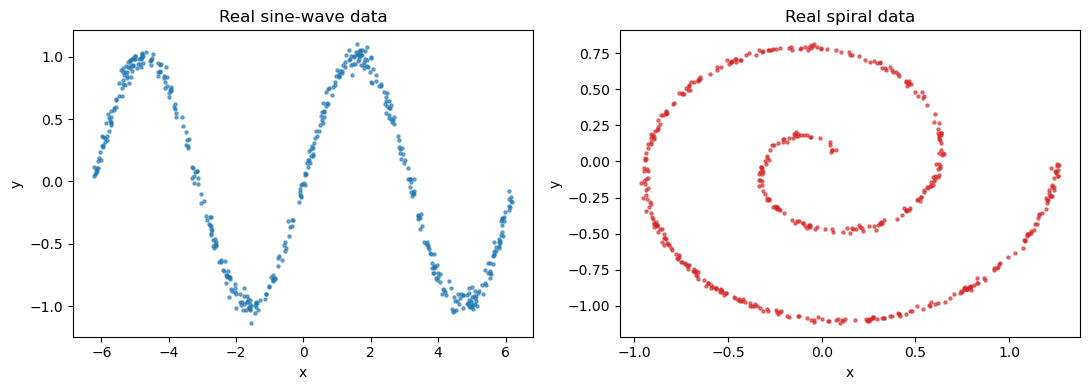

In [3]:
def sample_sine_wave(n_samples):
    """Points on y = sin(x) with small Gaussian noise. Shape (n, 2)."""
    x = np.random.uniform(-2 * np.pi, 2 * np.pi, n_samples)
    y = np.sin(x) + np.random.normal(0, 0.05, n_samples)
    return np.stack([x, y], axis=1).astype(np.float32)


def sample_spiral(n_samples, noise=0.1):
    """2D Archimedean spiral, scaled to roughly [-1.3, 1.3]. Shape (n, 2)."""
    theta = np.sqrt(np.random.rand(n_samples)) * 4 * np.pi  # angle grows with radius
    r = theta
    x = r * np.cos(theta) + np.random.normal(0, noise, n_samples)
    y = r * np.sin(theta) + np.random.normal(0, noise, n_samples)
    return (np.stack([x, y], axis=1) / 10.0).astype(np.float32)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
s = sample_sine_wave(500)
axes[0].scatter(s[:, 0], s[:, 1], s=5, alpha=0.6); axes[0].set_title("Real sine-wave data")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
sp = sample_spiral(500)
axes[1].scatter(sp[:, 0], sp[:, 1], s=5, alpha=0.6, color="tab:red"); axes[1].set_title("Real spiral data")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.tight_layout(); plt.savefig("real_distributions.png", dpi=150, bbox_inches="tight"); plt.show()

## 3. GAN with configurable activation & depth

The generator uses `BatchNorm` after each hidden layer for stability (the key ingredient that lets a spiral train). Activation and depth are arguments, so the same classes build both the original and the modified network in Task 3.

In [4]:
def make_activation(name):
    if name == "relu":
        return nn.ReLU()
    if name == "leaky_relu":
        return nn.LeakyReLU(0.2)
    raise ValueError(f"Unknown activation: {name}")


class Generator(nn.Module):
    """MLP: latent noise -> 2D point. BatchNorm + configurable depth/activation."""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=64, depth=2, activation="relu"):
        super().__init__()
        layers, width = [], latent_dim
        for _ in range(depth):
            layers += [nn.Linear(width, hidden_dim), nn.BatchNorm1d(hidden_dim), make_activation(activation)]
            width = hidden_dim
        layers.append(nn.Linear(width, 2))          # 2D output, no activation
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """MLP: 2D point -> real/fake probability. Configurable depth/activation."""
    def __init__(self, hidden_dim=64, depth=2, activation="leaky_relu"):
        super().__init__()
        layers, width = [], 2
        for _ in range(depth):
            layers += [nn.Linear(width, hidden_dim), make_activation(activation)]
            width = hidden_dim
        layers += [nn.Linear(width, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 4. Training loop

Adam with `betas=(0.5, 0.999)` (the standard GAN setting — `beta1=0.9` tends to destabilise training) and one-sided label smoothing (real target 0.9) to stop the discriminator overpowering the generator. G and D losses are stored per epoch.

In [5]:
def train_gan(data_sampler, generator, discriminator, n_epochs=10000,
              batch_size=128, lr=5e-4, latent_dim=LATENT_DIM, log_every=1000,
              label_smoothing=True, betas=(0.5, 0.999)):
    """Train a simple 2D GAN. Returns (g_losses, d_losses)."""
    generator.to(device); discriminator.to(device)
    criterion = nn.BCELoss()
    opt_g = optim.Adam(generator.parameters(), lr=lr, betas=betas)
    opt_d = optim.Adam(discriminator.parameters(), lr=lr, betas=betas)

    g_losses, d_losses = [], []
    real_target = 0.9 if label_smoothing else 1.0

    for epoch in range(n_epochs):
        # ---- Discriminator step ----
        real_data = torch.tensor(data_sampler(batch_size)).to(device)
        real_labels = torch.full((batch_size, 1), real_target, dtype=torch.float32).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        z = torch.randn(batch_size, latent_dim).to(device)
        fake_data = generator(z).detach()            # detach: don't update G here
        d_loss = (criterion(discriminator(real_data), real_labels)
                  + criterion(discriminator(fake_data), fake_labels))
        opt_d.zero_grad(); d_loss.backward(); opt_d.step()

        # ---- Generator step ----
        z = torch.randn(batch_size, latent_dim).to(device)
        g_labels = torch.ones(batch_size, 1).to(device)   # G wants D -> 1
        g_loss = criterion(discriminator(generator(z)), g_labels)
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()

        g_losses.append(g_loss.item()); d_losses.append(d_loss.item())
        if (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | D {d_loss.item():.4f} | G {g_loss.item():.4f}")
    return g_losses, d_losses

## 5. Plotting helpers

In [6]:
def plot_losses(g_losses, d_losses, title, fname=None):
    plt.figure(figsize=(6, 4))
    plt.plot(g_losses, label="Generator loss"); plt.plot(d_losses, label="Discriminator loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(title); plt.legend()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()


def generate(generator, n, latent_dim=LATENT_DIM):
    """Sample n fake points (generator in eval mode, needed for BatchNorm)."""
    generator.eval()
    with torch.no_grad():
        out = generator(torch.randn(n, latent_dim).to(device)).cpu().numpy()
    generator.train()
    return out


def plot_real_vs_fake(real_data, generator, title, fname=None):
    fake = generate(generator, 500)
    plt.figure(figsize=(6, 5))
    plt.scatter(real_data[:, 0], real_data[:, 1], s=8, alpha=0.5, label="Real")
    plt.scatter(fake[:, 0], fake[:, 1], s=8, alpha=0.5, label="Generated")
    plt.legend(); plt.title(title)
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

## Task 1 — Reproduce the sine-wave GAN

Epoch 1000/5000 | D 1.3462 | G 0.8394
Epoch 2000/5000 | D 1.3586 | G 0.8211
Epoch 3000/5000 | D 1.3645 | G 0.8181
Epoch 4000/5000 | D 1.3670 | G 0.7924
Epoch 5000/5000 | D 1.3555 | G 0.8251


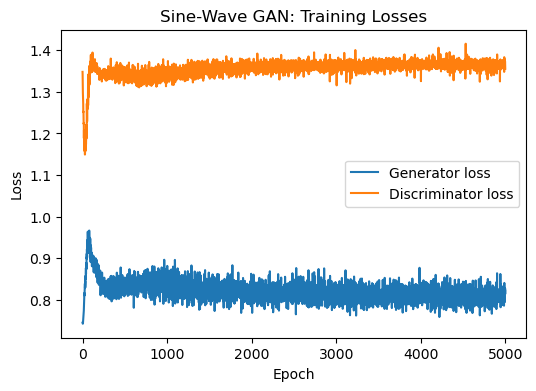

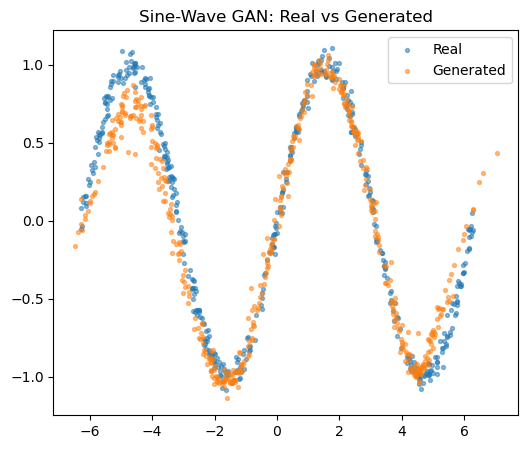

In [7]:
torch.manual_seed(42); np.random.seed(42)
gen_sine = Generator(depth=2, activation="relu")
disc_sine = Discriminator(depth=2, activation="leaky_relu")
gl, dl = train_gan(sample_sine_wave, gen_sine, disc_sine, n_epochs=5000)

plot_losses(gl, dl, "Sine-Wave GAN: Training Losses", "sine_losses.png")
plot_real_vs_fake(sample_sine_wave(500), gen_sine, "Sine-Wave GAN: Real vs Generated", "sine_real_vs_fake.png")

## Task 2 — New 2D distribution (spiral)

Epoch 1000/10000 | D 1.3629 | G 0.8079
Epoch 2000/10000 | D 1.3623 | G 0.8265
Epoch 3000/10000 | D 1.3462 | G 0.8032
Epoch 4000/10000 | D 1.3180 | G 0.8120
Epoch 5000/10000 | D 1.3161 | G 0.8598
Epoch 6000/10000 | D 1.3202 | G 0.8349
Epoch 7000/10000 | D 1.2858 | G 0.8628
Epoch 8000/10000 | D 1.2552 | G 0.8645
Epoch 9000/10000 | D 1.3047 | G 0.8190
Epoch 10000/10000 | D 1.3276 | G 0.8151


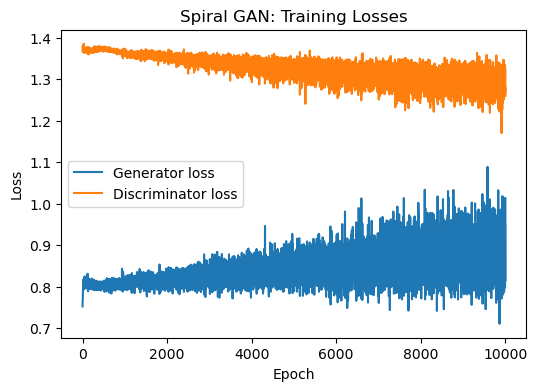

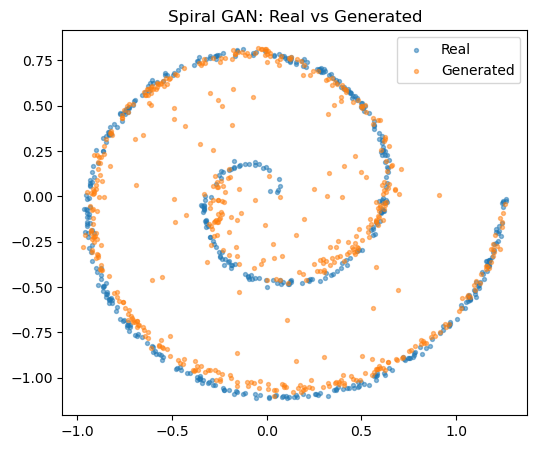

In [8]:
torch.manual_seed(42); np.random.seed(42)
gen_spiral = Generator(depth=2, activation="relu")
disc_spiral = Discriminator(depth=2, activation="leaky_relu")
gl, dl = train_gan(sample_spiral, gen_spiral, disc_spiral, n_epochs=10000)

plot_losses(gl, dl, "Spiral GAN: Training Losses", "spiral_losses.png")
plot_real_vs_fake(sample_spiral(500), gen_spiral, "Spiral GAN: Real vs Generated", "spiral_real_vs_fake.png")

## Task 3 — Modify the architecture & compare

**Controlled change** — only two things differ from the original; everything else (latent dim, width, learning rate, epochs, BatchNorm, label smoothing) is held identical.

| | Original | Modified |
|---|---|---|
| Activation | ReLU | **LeakyReLU(0.2)** |
| Hidden depth | 2 | **4** |

Epoch 1000/10000 | D 1.3629 | G 0.8079
Epoch 2000/10000 | D 1.3623 | G 0.8265
Epoch 3000/10000 | D 1.3462 | G 0.8032
Epoch 4000/10000 | D 1.3180 | G 0.8120
Epoch 5000/10000 | D 1.3161 | G 0.8598
Epoch 6000/10000 | D 1.3202 | G 0.8349
Epoch 7000/10000 | D 1.2858 | G 0.8628
Epoch 8000/10000 | D 1.2552 | G 0.8645
Epoch 9000/10000 | D 1.3047 | G 0.8190
Epoch 10000/10000 | D 1.3276 | G 0.8151
Epoch 1000/10000 | D 1.2356 | G 1.0780
Epoch 2000/10000 | D 1.2095 | G 1.3149
Epoch 3000/10000 | D 1.1865 | G 1.0817
Epoch 4000/10000 | D 1.1064 | G 1.7878
Epoch 5000/10000 | D 1.3255 | G 1.2791
Epoch 6000/10000 | D 1.1713 | G 1.2262
Epoch 7000/10000 | D 1.2673 | G 0.9410
Epoch 8000/10000 | D 1.2516 | G 0.8865
Epoch 9000/10000 | D 1.3184 | G 1.0468
Epoch 10000/10000 | D 1.2497 | G 1.1947


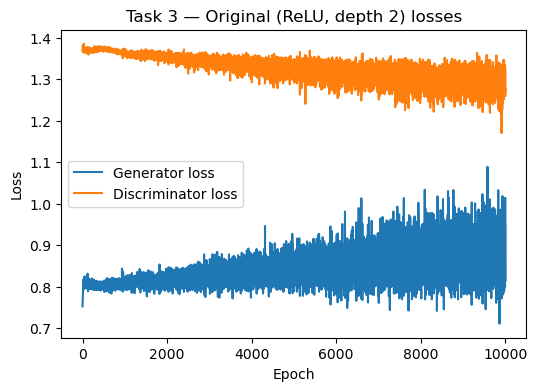

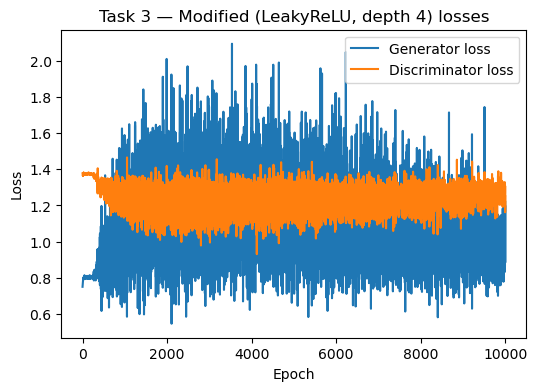

In [9]:
# --- Original architecture (ReLU, depth 2) ---
torch.manual_seed(42); np.random.seed(42)
gen_orig = Generator(depth=2, activation="relu")
disc_orig = Discriminator(depth=2, activation="leaky_relu")
gl_o, dl_o = train_gan(sample_spiral, gen_orig, disc_orig, n_epochs=10000)

# --- Modified architecture (LeakyReLU, depth 4) -- identical settings otherwise ---
torch.manual_seed(42); np.random.seed(42)
gen_mod = Generator(depth=4, activation="leaky_relu")
disc_mod = Discriminator(depth=4, activation="leaky_relu")
gl_m, dl_m = train_gan(sample_spiral, gen_mod, disc_mod, n_epochs=10000)

plot_losses(gl_o, dl_o, "Task 3 — Original (ReLU, depth 2) losses", "task3_original_losses.png")
plot_losses(gl_m, dl_m, "Task 3 — Modified (LeakyReLU, depth 4) losses", "task3_modified_losses.png")

### Visual comparison: real vs original vs modified

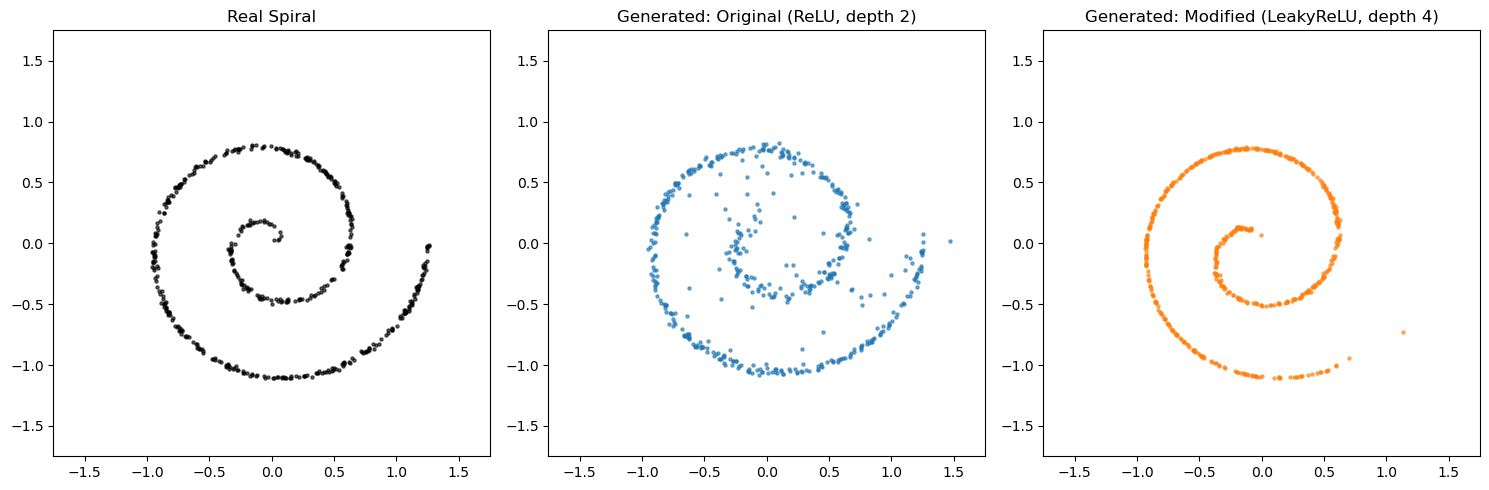

In [10]:
real_plot = sample_spiral(500)
fake_orig = generate(gen_orig, 500)
fake_mod = generate(gen_mod, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (data, title, color) in zip(axes, [
    (real_plot, "Real Spiral", "black"),
    (fake_orig, "Generated: Original (ReLU, depth 2)", "tab:blue"),
    (fake_mod, "Generated: Modified (LeakyReLU, depth 4)", "tab:orange"),
]):
    ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.6, color=color)
    ax.set_title(title); ax.set_xlim(-1.75, 1.75); ax.set_ylim(-1.75, 1.75)
plt.tight_layout(); plt.savefig("task3_comparison.png", dpi=150); plt.show()

## Summary

* **Task 1** — reproduced the tutorial sine-wave GAN; generated points trace the curve.
* **Task 2** — modelled a new 2D distribution (spiral). Stabilisation (BatchNorm + `betas=(0.5,0.999)` + label smoothing + sufficient epochs) is what allows a vanilla GAN to learn the spiral rather than collapsing to a blob.
* **Task 3** — changed only activation (ReLU→LeakyReLU) and depth (2→4) on top of the same stable base, and compared the generated spirals side by side.

Describe the figures as they actually appear on your run.

---

# Part 2: Real-World GAN Applications


## TensorFlow/Keras setup (shared by the TensorFlow parts of this notebook)

The image GANs in this notebook are built with **TensorFlow/Keras** (the assignment
explicitly permits PyTorch *or* TensorFlow/Keras for Part 2). The DCGAN generator uses
fractionally-strided `Conv2DTranspose` layers with BatchNorm + ReLU; the discriminator
uses strided `Conv2D` + LeakyReLU. Training uses a two-tape `tf.GradientTape` step with
one-sided label smoothing. FID reuses InceptionV3's 2048-d pooled features.

In [11]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # quieten TF C++ logs

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential, optimizers, losses
from tensorflow.keras.applications import InceptionV3
import matplotlib.pyplot as plt

# Let TF grow GPU memory on demand instead of grabbing all of it, so the PyTorch
# parts of this same notebook still have room on the GPU.
for _gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except Exception:
        pass

TF_SEED = 1337
tf.random.set_seed(TF_SEED)
np.random.seed(TF_SEED)

TF_RESULTS_DIR = "results_set1"
os.makedirs(TF_RESULTS_DIR, exist_ok=True)
print("TensorFlow", tf.__version__, "| Keras", tf.keras.__version__, "| results ->", TF_RESULTS_DIR)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.21.0 | Keras 3.12.3 | results -> results_set1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
# ----------------------------------------------------------------------------- #
# Frechet Inception Distance (TensorFlow) - shared by every TF image part.
# ----------------------------------------------------------------------------- #
_inception_fid_model = None


def _get_inception_fid():
    """Lazily build the InceptionV3 feature extractor (ImageNet weights)."""
    global _inception_fid_model
    if _inception_fid_model is None:
        _inception_fid_model = InceptionV3(include_top=False, pooling="avg",
                                           weights="imagenet", input_shape=(299, 299, 3))
    return _inception_fid_model


def inception_features(images_unit_range, batch=50):
    """(N, H, W, 1) images in [0, 1] -> (N, 2048) InceptionV3 pooled features."""
    model = _get_inception_fid()
    collected = []
    for start in range(0, images_unit_range.shape[0], batch):
        chunk = tf.convert_to_tensor(images_unit_range[start:start + batch], dtype=tf.float32)
        chunk = tf.image.resize(chunk, (299, 299))
        if chunk.shape[-1] == 1:
            chunk = tf.repeat(chunk, 3, axis=-1)
        chunk = tf.keras.applications.inception_v3.preprocess_input(chunk * 255.0)
        collected.append(model.predict(chunk, verbose=0))
    return np.concatenate(collected, axis=0)


def frechet_inception_distance(real_unit_range, fake_unit_range, eps=1e-6):
    """FID between two image sets given in the [0, 1] range (lower is better)."""
    import scipy.linalg
    real_features = inception_features(real_unit_range)
    fake_features = inception_features(fake_unit_range)
    mu_real, mu_fake = real_features.mean(0), fake_features.mean(0)
    cov_real = np.cov(real_features, rowvar=False)
    cov_fake = np.cov(fake_features, rowvar=False)
    mean_diff = mu_real - mu_fake
    root = scipy.linalg.sqrtm(cov_real @ cov_fake)
    if isinstance(root, tuple):
        root = root[0]
    if not np.isfinite(root).all():
        offset = np.eye(cov_real.shape[0]) * eps
        root = scipy.linalg.sqrtm((cov_real + offset) @ (cov_fake + offset))
        if isinstance(root, tuple):
            root = root[0]
    if np.iscomplexobj(root):
        root = root.real
    return float(mean_diff @ mean_diff + np.trace(cov_real + cov_fake - 2.0 * root))

In [13]:
# ----------------------------------------------------------------------------- #
# Preprocessing + plotting helpers for the TF image parts.
# ----------------------------------------------------------------------------- #
def preprocess_tf_images(images_uint8, size=32):
    """(N, H, W) uint8 -> (N, size, size, 1) float32 in [-1, 1] (channel-last)."""
    x = images_uint8.astype("float32")[..., None] / 127.5 - 1.0
    if x.shape[1] != size:
        x = tf.image.resize(x, (size, size)).numpy().astype("float32")
    return x


def to_unit_range(images_pm1):
    """[-1, 1] -> [0, 1] for FID."""
    return (np.clip(images_pm1, -1.0, 1.0) + 1.0) / 2.0


def tf_show_grid(images_pm1, title, path=None, ncols=8):
    """Render a grid of channel-last images given in [-1, 1]."""
    imgs = to_unit_range(np.asarray(images_pm1))
    count = imgs.shape[0]
    nrows = int(np.ceil(count / ncols))
    plt.figure(figsize=(ncols, nrows))
    for i in range(count):
        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(imgs[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    if path:
        plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def tf_show_real_vs_fake(real_pm1, fake_pm1, title, path=None, shown=32):
    """Side-by-side real vs generated grids (channel-last, [-1, 1])."""
    figure, axes = plt.subplots(1, 2, figsize=(12, 6))
    for axis, batch, name in ((axes[0], real_pm1, "Real"), (axes[1], fake_pm1, "Generated")):
        imgs = to_unit_range(np.asarray(batch)[:shown])
        side = int(np.ceil(np.sqrt(imgs.shape[0])))
        canvas = np.ones((side * 32, side * 32))
        for i in range(imgs.shape[0]):
            r, c = divmod(i, side)
            canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = imgs[i, :, :, 0]
        axis.imshow(canvas, cmap="gray"); axis.set_title(name); axis.axis("off")
    figure.suptitle(title)
    if path:
        figure.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def tf_show_epoch_progression(snapshots, title, path=None):
    """snapshots: list of (epoch, image_batch[-1,1]) -> side-by-side grids across epochs."""
    if not snapshots:
        return
    cols = len(snapshots)
    figure, axes = plt.subplots(1, cols, figsize=(3.0 * cols, 3.2))
    if cols == 1:
        axes = [axes]
    for axis, (epoch, batch) in zip(axes, snapshots):
        imgs = to_unit_range(np.asarray(batch)[:16])
        canvas = np.ones((4 * 32, 4 * 32))
        for i in range(min(16, imgs.shape[0])):
            r, c = divmod(i, 4)
            canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = imgs[i, :, :, 0]
        axis.imshow(canvas, cmap="gray"); axis.set_title(f"epoch {epoch}"); axis.axis("off")
    figure.suptitle(title)
    if path:
        figure.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def tf_plot_losses(discriminator_history, generator_history, title, path=None):
    """Plot discriminator vs generator loss traces."""
    plt.figure(figsize=(8, 4))
    plt.plot(discriminator_history, label="Discriminator", color="#1f77b4", alpha=0.85)
    plt.plot(generator_history, label="Generator", color="#d62728", alpha=0.85)
    plt.title(title); plt.xlabel("training step"); plt.ylabel("BCE loss")
    plt.legend(); plt.grid(alpha=0.2)
    if path:
        plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

In [14]:
# ----------------------------------------------------------------------------- #
# Shared DCGAN + conditional-DCGAN builders and trainers (Keras).
# ----------------------------------------------------------------------------- #
def _kernel_init(name):
    """Map an init name to a Keras initializer (genuine init differentiation)."""
    if name == "dcgan":
        return tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02)
    if name == "he":
        return "he_normal"
    return "glorot_uniform"


def build_dcgan_generator(latent_dim, feature_maps=64, weight_init="dcgan"):
    """Latent vector -> (32, 32, 1) image in [-1, 1] via fractionally-strided convs."""
    init = _kernel_init(weight_init)
    return Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(4 * 4 * feature_maps * 4, use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(), layers.ReLU(),
        layers.Reshape((4, 4, feature_maps * 4)),
        layers.Conv2DTranspose(feature_maps * 2, 4, 2, "same", use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(), layers.ReLU(),                                       # 8x8
        layers.Conv2DTranspose(feature_maps, 4, 2, "same", use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(), layers.ReLU(),                                       # 16x16
        layers.Conv2DTranspose(1, 4, 2, "same", use_bias=False, activation="tanh", kernel_initializer=init),
    ], name="dcgan_generator")                                                            # 32x32


def build_dcgan_discriminator(feature_maps=64, weight_init="dcgan", dropout=0.0):
    """(32, 32, 1) image -> single real/fake logit (no sigmoid)."""
    init = _kernel_init(weight_init)
    model = Sequential(name="dcgan_discriminator")
    model.add(layers.Input(shape=(32, 32, 1)))
    model.add(layers.Conv2D(feature_maps, 4, 2, "same", kernel_initializer=init))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Conv2D(feature_maps * 2, 4, 2, "same", kernel_initializer=init))
    model.add(layers.BatchNormalization()); model.add(layers.LeakyReLU(0.2))
    model.add(layers.Conv2D(feature_maps * 4, 4, 2, "same", kernel_initializer=init))
    model.add(layers.BatchNormalization()); model.add(layers.LeakyReLU(0.2))
    if dropout > 0:
        model.add(layers.Dropout(dropout))
    model.add(layers.Flatten())
    model.add(layers.Dense(1, kernel_initializer=init))
    return model


def train_dcgan(generator, discriminator, dataset, epochs, latent_dim,
                learning_rate=2e-4, beta_1=0.5, label_smoothing=0.9, snapshots=5):
    """Train an unconditional DCGAN; return (d_history, g_history, epoch_snapshots)."""
    g_opt = optimizers.Adam(learning_rate, beta_1=beta_1)
    d_opt = optimizers.Adam(learning_rate, beta_1=beta_1)
    bce = losses.BinaryCrossentropy(from_logits=True)

    @tf.function
    def step(real_images):
        batch = tf.shape(real_images)[0]
        noise = tf.random.normal((batch, latent_dim))
        with tf.GradientTape() as d_tape, tf.GradientTape() as g_tape:
            fake_images = generator(noise, training=True)
            real_logits = discriminator(real_images, training=True)
            fake_logits = discriminator(fake_images, training=True)
            d_loss = (bce(tf.ones_like(real_logits) * label_smoothing, real_logits)
                      + bce(tf.zeros_like(fake_logits), fake_logits))
            g_loss = bce(tf.ones_like(fake_logits), fake_logits)
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))
        g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                  generator.trainable_variables))
        return d_loss, g_loss

    d_history, g_history, progression = [], [], []
    snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, epochs, snapshots)))
    fixed_noise = tf.random.normal((16, latent_dim))
    for epoch in range(1, epochs + 1):
        d_last, g_last = 0.0, 0.0
        for real_images in dataset:
            d_last, g_last = step(real_images)
            d_history.append(float(d_last)); g_history.append(float(g_last))
        print(f"epoch {epoch:>3}/{epochs} | D={float(d_last):.4f} | G={float(g_last):.4f}")
        if epoch in snapshot_epochs:
            progression.append((epoch, generator(fixed_noise, training=False).numpy()))
    return d_history, g_history, progression


@tf.autograph.experimental.do_not_convert
def generate_tf_images(generator, count, latent_dim):
    """Sample a batch of generated images in [-1, 1] from a trained generator."""
    noise = tf.random.normal((count, latent_dim))
    return generator(noise, training=False).numpy()

In [15]:
# ----------------------------------------------------------------------------- #
# Conditional DCGAN (class-conditioned) builders and trainer - used by the cGAN
# extension. Labels are embedded and concatenated (generator) / injected as an extra
# image channel (discriminator), mirroring the standard conditional-DCGAN recipe.
# ----------------------------------------------------------------------------- #
def build_conditional_generator(num_classes, latent_dim, feature_maps=64,
                                embedding_dim=50, weight_init="dcgan"):
    init = _kernel_init(weight_init)
    noise_input = layers.Input(shape=(latent_dim,))
    label_input = layers.Input(shape=(), dtype="int32")
    label_vector = layers.Embedding(num_classes, embedding_dim)(label_input)
    x = layers.Concatenate()([noise_input, label_vector])
    x = layers.Dense(4 * 4 * feature_maps * 4, use_bias=False, kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Reshape((4, 4, feature_maps * 4))(x)
    x = layers.Conv2DTranspose(feature_maps * 2, 4, 2, "same", use_bias=False, kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(feature_maps, 4, 2, "same", use_bias=False, kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    output = layers.Conv2DTranspose(1, 4, 2, "same", use_bias=False, activation="tanh", kernel_initializer=init)(x)
    return Model([noise_input, label_input], output, name="conditional_generator")


def build_conditional_discriminator(num_classes, feature_maps=64, image_size=32, weight_init="dcgan"):
    init = _kernel_init(weight_init)
    image_input = layers.Input(shape=(image_size, image_size, 1))
    label_input = layers.Input(shape=(), dtype="int32")
    label_map = layers.Embedding(num_classes, image_size * image_size)(label_input)
    label_map = layers.Reshape((image_size, image_size, 1))(label_map)
    x = layers.Concatenate()([image_input, label_map])
    x = layers.Conv2D(feature_maps, 4, 2, "same", kernel_initializer=init)(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(feature_maps * 2, 4, 2, "same", kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(feature_maps * 4, 4, 2, "same", kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    output = layers.Dense(1, kernel_initializer=init)(x)
    return Model([image_input, label_input], output, name="conditional_discriminator")


def train_conditional_dcgan(generator, discriminator, dataset, epochs, num_classes, latent_dim,
                            learning_rate=1e-4, beta_1=0.5, label_smoothing=0.9):
    """Train the conditional DCGAN; dataset yields (images, labels)."""
    g_opt = optimizers.Adam(learning_rate, beta_1=beta_1)
    d_opt = optimizers.Adam(learning_rate, beta_1=beta_1)
    bce = losses.BinaryCrossentropy(from_logits=True)

    @tf.function
    def step(real_images, real_labels):
        batch = tf.shape(real_images)[0]
        noise = tf.random.normal((batch, latent_dim))
        sampled_labels = tf.random.uniform((batch,), 0, num_classes, dtype=tf.int32)
        with tf.GradientTape() as d_tape, tf.GradientTape() as g_tape:
            fake_images = generator([noise, sampled_labels], training=True)
            real_logits = discriminator([real_images, real_labels], training=True)
            fake_logits = discriminator([fake_images, sampled_labels], training=True)
            d_loss = (bce(tf.ones_like(real_logits) * label_smoothing, real_logits)
                      + bce(tf.zeros_like(fake_logits), fake_logits))
            g_loss = bce(tf.ones_like(fake_logits), fake_logits)
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))
        g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                  generator.trainable_variables))
        return d_loss, g_loss

    d_history, g_history = [], []
    for epoch in range(1, epochs + 1):
        d_last, g_last = 0.0, 0.0
        for real_images, real_labels in dataset:
            d_last, g_last = step(real_images, real_labels)
            d_history.append(float(d_last)); g_history.append(float(g_last))
        print(f"[cGAN] epoch {epoch:>3}/{epochs} | D={float(d_last):.4f} | G={float(g_last):.4f}")
    return d_history, g_history

# Part 2.1 - OCTMNIST retinal images with a DCGAN (TensorFlow/Keras)

OCTMNIST (MedMNIST) holds 28x28 grayscale optical-coherence-tomography retinal scans
across 4 diagnostic classes. We explore the data, train a **TensorFlow/Keras DCGAN** to
synthesise retinal images, evaluate with FID, and finish with a conditional-GAN extension
that generates a chosen class on demand.

In [16]:
# --- Part 2.1 configuration (OCTMNIST DCGAN, TensorFlow) ---
OCT_LATENT = 100
OCT_NGF = 64
OCT_NDF = 64
OCT_LR = 0.0002
OCT_BETA1 = 0.5
OCT_EPOCHS = 30
OCT_BATCH = 128
OCT_MAX_IMAGES = 30000
OCT_FID_SAMPLES = 2000
OCT_INIT = "dcgan"
OCT_CGAN_EMB = 50
OCT_CGAN_LR = 0.0001
OCT_CGAN_EPOCHS = 30
print("OCTMNIST TF config:", dict(latent=OCT_LATENT, ngf=OCT_NGF, ndf=OCT_NDF, lr=OCT_LR,
                                  epochs=OCT_EPOCHS, batch=OCT_BATCH, init=OCT_INIT))

OCTMNIST TF config: {'latent': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'epochs': 30, 'batch': 128, 'init': 'dcgan'}


## 2.1.1 - Load and explore OCTMNIST

100%|██████████| 54.9M/54.9M [00:17<00:00, 3.14MB/s]


OCTMNIST classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}
OCTMNIST train images: (97477, 28, 28)


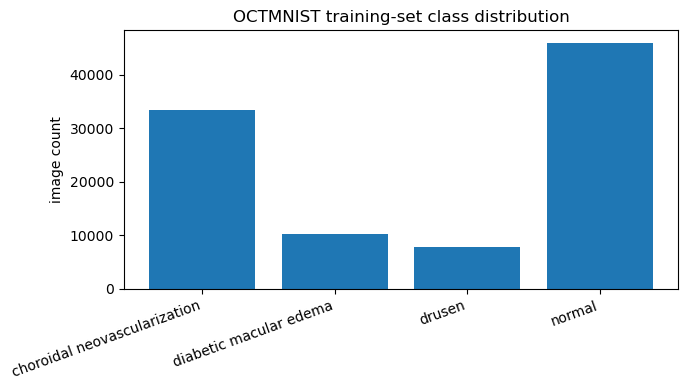

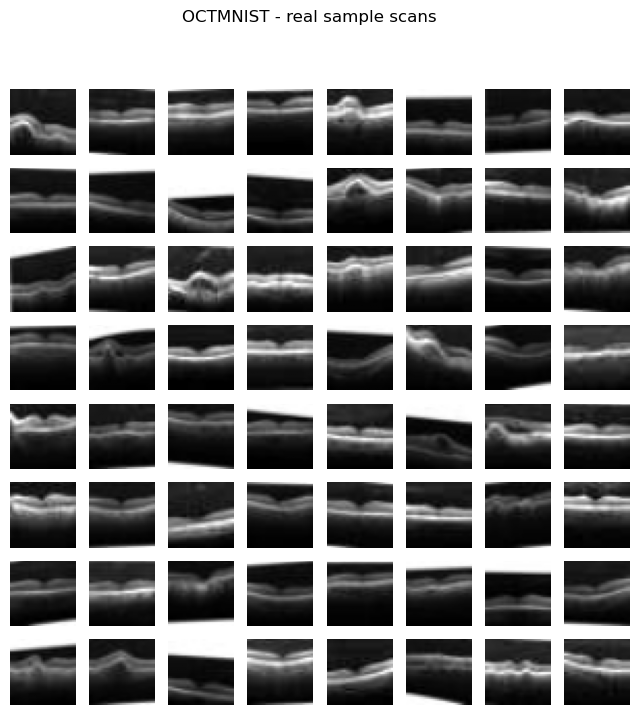

In [17]:
import sys
import subprocess

# MedMNIST may not be preinstalled; --no-deps keeps the
# preinstalled numpy/torch/etc. untouched (MedMNIST here is only used for its numpy arrays).
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "medmnist"], check=False)

from medmnist import OCTMNIST, INFO

octmnist_class_names = INFO["octmnist"]["label"]
octmnist_train = OCTMNIST(split="train", download=True)
octmnist_images = octmnist_train.imgs                 # (N, 28, 28) uint8
octmnist_labels = octmnist_train.labels.flatten()      # (N,)
octmnist_num_classes = len(octmnist_class_names)
print("OCTMNIST classes:", octmnist_class_names)
print("OCTMNIST train images:", octmnist_images.shape)

# Class distribution.
unique_classes, class_counts = np.unique(octmnist_labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([octmnist_class_names[str(int(c))] for c in unique_classes], class_counts, color="#1f77b4")
plt.title("OCTMNIST training-set class distribution")
plt.ylabel("image count"); plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(TF_RESULTS_DIR, "octmnist_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

# Sample of real scans.
tf_show_grid(preprocess_tf_images(octmnist_images[:64]), "OCTMNIST - real sample scans",
             os.path.join(TF_RESULTS_DIR, "octmnist_real_samples.png"))

## 2.1.2 - Build and train the DCGAN

Model: "dcgan_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 1)      │         1,024 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,083,136 (4.13 MB)

 Trainable params: 1,074,560 (4.10 MB)

 Non-trainable params: 8,576 (33.50 KB)

epoch   1/30 | D=0.3881 | G=4.1384
epoch   2/30 | D=0.4291 | G=3.2283
epoch   3/30 | D=0.6998 | G=1.4572
epoch   4/30 | D=0.8546 | G=1.0768
epoch   5/30 | D=0.6137 | G=1.6303
epoch   6/30 | D=1.2322 | G=3.6921
epoch   7/30 | D=0.9889 | G=1.0542
epoch   8/30 | D=0.5930 | G=1.7545
epoch   9/30 | D=0.4082 | G=2.8687
epoch  10/30 | D=0.6095 | G=1.6623
epoch  11/30 | D=0.3748 | G=3.6778
epoch  12/30 | D=1.1329 | G=2.3761
epoch  13/30 | D=0.4502 | G=3.2339
epoch  14/30 | D=0.6403 | G=1.5251
epoch  15/30 | D=0.3448 | G=4.3666
epoch  16/30 | D=0.7860 | G=3.1730
epoch  17/30 | D=0.5825 | G=1.9562
epoch  18/30 | D=0.4205 | G=2.7882
epoch  19/30 | D=0.3885 | G=4.5812
epoch  20/30 | D=0.4700 | G=2.2253
epoch  21/30 | D=0.7458 | G=3.2044
epoch  22/30 | D=0.7537 | G=3.6696
epoch  23/30 | D=0.3504 | G=4.4706
epoch  24/30 | D=0.3588 | G=4.5931
epoch  25/30 | D=0.7029 | G=5.8578
epoch  26/30 | D=0.3582 | G=4.3944
epoch  27/30 | D=0.3971 | G=3.6493
epoch  28/30 | D=0.4496 | G=2.5705
epoch  29/30 | D=0.3

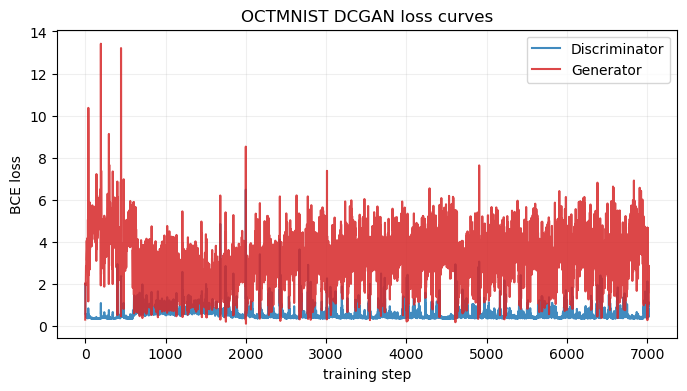

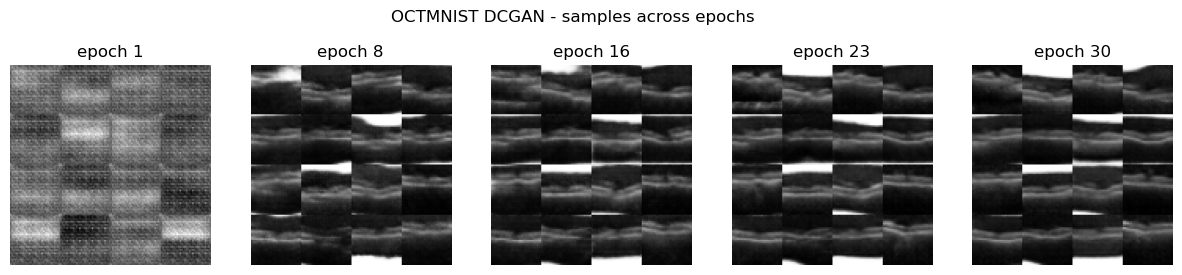

In [18]:
np.random.seed(TF_SEED); tf.random.set_seed(TF_SEED)

# Subsample for a sane training time, then preprocess to (N, 32, 32, 1) in [-1, 1].
octmnist_subset = np.random.permutation(len(octmnist_images))[:OCT_MAX_IMAGES]
octmnist_x = preprocess_tf_images(octmnist_images[octmnist_subset])
octmnist_dataset = (tf.data.Dataset.from_tensor_slices(octmnist_x)
                    .shuffle(min(len(octmnist_x), 10000))
                    .batch(OCT_BATCH, drop_remainder=True)
                    .prefetch(tf.data.AUTOTUNE))

octmnist_generator = build_dcgan_generator(OCT_LATENT, OCT_NGF, weight_init=OCT_INIT)
octmnist_discriminator = build_dcgan_discriminator(OCT_NDF, weight_init=OCT_INIT)
octmnist_generator.summary()

octmnist_d_hist, octmnist_g_hist, octmnist_snaps = train_dcgan(
    octmnist_generator, octmnist_discriminator, octmnist_dataset,
    OCT_EPOCHS, OCT_LATENT, learning_rate=OCT_LR, beta_1=OCT_BETA1)

tf_plot_losses(octmnist_d_hist, octmnist_g_hist, "OCTMNIST DCGAN loss curves",
               os.path.join(TF_RESULTS_DIR, "octmnist_loss_curves.png"))
tf_show_epoch_progression(octmnist_snaps, "OCTMNIST DCGAN - samples across epochs",
                          os.path.join(TF_RESULTS_DIR, "octmnist_progression.png"))

## 2.1.3 - Generate, compare real vs fake, and compute FID

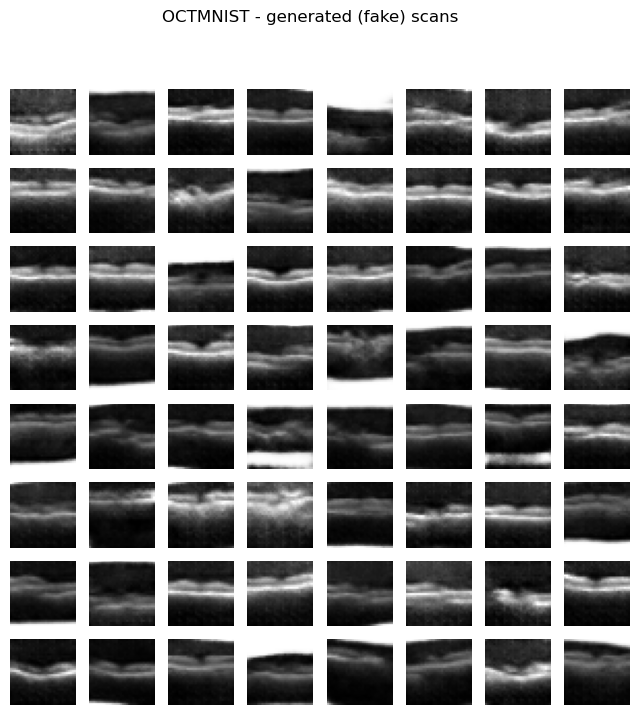

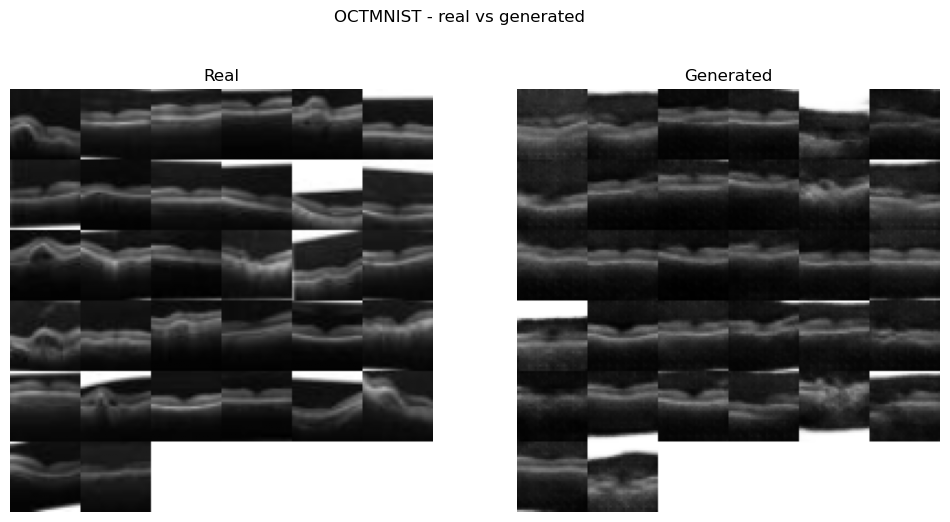

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
OCTMNIST DCGAN FID (lower is better): 97.12


In [19]:
octmnist_fake = generate_tf_images(octmnist_generator, OCT_FID_SAMPLES, OCT_LATENT)
tf_show_grid(octmnist_fake[:64], "OCTMNIST - generated (fake) scans",
             os.path.join(TF_RESULTS_DIR, "octmnist_fake_samples.png"))

# Explicit side-by-side real vs generated (brief: "compare real vs fake").
tf_show_real_vs_fake(preprocess_tf_images(octmnist_images[:32]), octmnist_fake[:32],
                     "OCTMNIST - real vs generated", os.path.join(TF_RESULTS_DIR, "octmnist_real_vs_fake.png"))

# FID on an independent real sample, preprocessed identically.
octmnist_fid_idx = np.random.permutation(len(octmnist_images))[:OCT_FID_SAMPLES]
octmnist_real_unit = to_unit_range(preprocess_tf_images(octmnist_images[octmnist_fid_idx]))
octmnist_fid = frechet_inception_distance(octmnist_real_unit, to_unit_range(octmnist_fake))
print(f"OCTMNIST DCGAN FID (lower is better): {octmnist_fid:.2f}")

## 2.1.4 - Reflection (write these up in your own words)

- Do the generated scans reproduce the layered retinal texture, or are there obvious
  artefacts (blur, checkerboarding, repeated blobs)? Relate the loss curves to what you
  see (a discriminator loss collapsing to 0 usually means mode collapse).
- Report the FID and note that run-to-run variance is expected for GANs (reduced here
  with a fixed seed).
- **GANs generating "ducks" (hallucination):** a GAN can synthesise plausible-looking
  structure that was never in the training data - a fabricated feature in a retinal scan
  could be mistaken for pathology, which is why synthetic medical images must be handled
  carefully. Confirm with the tutors whether this discussion line is required.

## 2.1 (extension) - Conditional GAN (generate a chosen class on demand)

The label is embedded and concatenated with the latent (generator) and injected as an
extra image channel (discriminator). Class-balanced oversampling counters OCTMNIST's
imbalance, and a slower discriminator learning rate (TTUR) keeps training stable.

[cGAN] epoch   1/30 | D=0.3596 | G=4.1678
[cGAN] epoch   2/30 | D=0.3804 | G=3.6610
[cGAN] epoch   3/30 | D=0.4403 | G=2.5900
[cGAN] epoch   4/30 | D=0.8284 | G=2.4318
[cGAN] epoch   5/30 | D=0.4756 | G=2.8263
[cGAN] epoch   6/30 | D=0.5263 | G=2.2332
[cGAN] epoch   7/30 | D=0.7213 | G=4.6041
[cGAN] epoch   8/30 | D=0.5308 | G=2.1918
[cGAN] epoch   9/30 | D=0.5021 | G=2.6864
[cGAN] epoch  10/30 | D=0.6894 | G=1.3347
[cGAN] epoch  11/30 | D=0.7254 | G=3.2459
[cGAN] epoch  12/30 | D=0.6719 | G=3.9296
[cGAN] epoch  13/30 | D=0.3935 | G=3.2113
[cGAN] epoch  14/30 | D=0.3890 | G=3.4651
[cGAN] epoch  15/30 | D=0.3774 | G=3.4153
[cGAN] epoch  16/30 | D=0.4819 | G=2.5771
[cGAN] epoch  17/30 | D=0.4391 | G=3.4329
[cGAN] epoch  18/30 | D=0.4348 | G=3.2772
[cGAN] epoch  19/30 | D=0.3565 | G=4.1744
[cGAN] epoch  20/30 | D=0.3423 | G=4.8254
[cGAN] epoch  21/30 | D=0.4653 | G=3.6896
[cGAN] epoch  22/30 | D=0.3748 | G=4.3302
[cGAN] epoch  23/30 | D=0.4701 | G=3.9529
[cGAN] epoch  24/30 | D=0.3528 | G

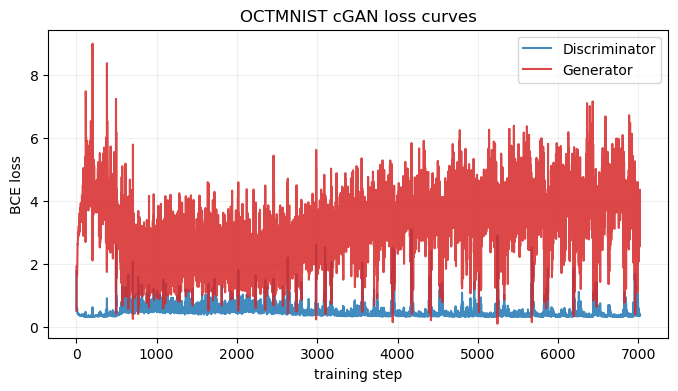

In [20]:
np.random.seed(TF_SEED); tf.random.set_seed(TF_SEED)

# Class-balanced dataset: oversample each class to an equal count so the cGAN learns the
# minority classes instead of ignoring them.
per_class_count = max(1, OCT_MAX_IMAGES // octmnist_num_classes)
balanced_index = np.concatenate([
    np.random.choice(np.where(octmnist_labels == c)[0], per_class_count, replace=True)
    for c in range(octmnist_num_classes)
])
np.random.shuffle(balanced_index)
octmnist_x_balanced = preprocess_tf_images(octmnist_images[balanced_index])
octmnist_y_balanced = octmnist_labels[balanced_index].astype("int32")
conditional_dataset = (tf.data.Dataset.from_tensor_slices((octmnist_x_balanced, octmnist_y_balanced))
                       .shuffle(min(len(balanced_index), 10000))
                       .batch(OCT_BATCH, drop_remainder=True)
                       .prefetch(tf.data.AUTOTUNE))

conditional_generator = build_conditional_generator(
    octmnist_num_classes, OCT_LATENT, OCT_NGF, embedding_dim=OCT_CGAN_EMB, weight_init=OCT_INIT)
conditional_discriminator = build_conditional_discriminator(
    octmnist_num_classes, OCT_NDF, weight_init=OCT_INIT)

conditional_d_hist, conditional_g_hist = train_conditional_dcgan(
    conditional_generator, conditional_discriminator, conditional_dataset,
    OCT_CGAN_EPOCHS, octmnist_num_classes, OCT_LATENT, learning_rate=OCT_CGAN_LR, beta_1=OCT_BETA1)
tf_plot_losses(conditional_d_hist, conditional_g_hist, "OCTMNIST cGAN loss curves",
               os.path.join(TF_RESULTS_DIR, "octmnist_cgan_loss_curves.png"))

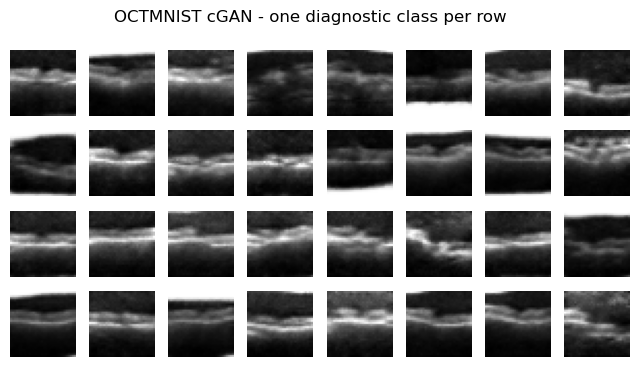

In [21]:
# One diagnostic class per row to show class-conditioned control.
conditional_rows = []
for class_index in range(octmnist_num_classes):
    noise = tf.random.normal((8, OCT_LATENT))
    labels_row = tf.fill((8,), class_index)
    conditional_rows.append(conditional_generator([noise, labels_row], training=False).numpy())
tf_show_grid(np.concatenate(conditional_rows, axis=0),
             "OCTMNIST cGAN - one diagnostic class per row",
             os.path.join(TF_RESULTS_DIR, "octmnist_cgan_per_class.png"), ncols=8)

---

# Part 2.2 - Cybersecurity: CICIDS 2017 (PyTorch, MLP tabular GAN)

This part stays in **PyTorch** (feature-vector GAN on tabular flow data - not a DCGAN, since the data are not images).

## 1. Setup

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 11
torch.manual_seed(SEED); np.random.seed(SEED)

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if dev.type == "cuda":
    try:
        _ = (torch.randn(4, 4, device=dev) @ torch.randn(4, 4, device=dev)); torch.cuda.synchronize()
    except RuntimeError:
        print("CUDA kernel launch failed - falling back to CPU. Enable the GPU accelerator for this runtime.")
        dev = torch.device("cpu")

OUT_CYBER = "results_set1"
os.makedirs(OUT_CYBER, exist_ok=True)

# Training budget in one place. Set FAST=True for a quick smoke test.
FAST = False
EPOCHS = 3 if FAST else 60
BATCH = 256
Z_DIM_CYBER = 32
MAX_TRAIN_PER_CLASS = 2000 if FAST else 20000   # cap rows/class so training stays fast
print(f"device={dev} | epochs={EPOCHS} | out={OUT_CYBER}")

device=cuda | epochs=60 | out=results_set1


## 2. Load and explore all day-files (features + overall class balance)

In [ ]:
import os
import glob

# ---------------------------------------------------------------------------- #
# CICIDS 2017 data source (HYBRID): use a local folder of the eight day-CSVs if
# it is available, otherwise download the dataset straight from Kaggle
# (chethuhn/network-intrusion-dataset, the source named in the brief) via
# kagglehub. The download path needs Internet: ON; on Kaggle it resolves with
# no extra credentials, and off-Kaggle it uses your ~/.kaggle/kaggle.json.
# ---------------------------------------------------------------------------- #
CICIDS_DIR = "."   # optional: point at a local folder of the CSVs; auto-downloads if not found

CICIDS_CSV_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]


def _find_cicids_csvs(root):
    """All CICIDS day-CSVs found anywhere under `root` (searches subfolders)."""
    days = ("Monday", "Tuesday", "Wednesday", "Thursday", "Friday")
    found = glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    return sorted(p for p in found if any(d in os.path.basename(p) for d in days))


# 1) Prefer a local folder if it already holds all eight files.
local_files = [os.path.join(CICIDS_DIR, name) for name in CICIDS_CSV_FILES]
if all(os.path.exists(p) for p in local_files):
    day_files = local_files
    print(f"Using local CICIDS 2017 CSVs from: {os.path.abspath(CICIDS_DIR)}")
else:
    # 2) Otherwise download from Kaggle via kagglehub and locate the CSVs.
    print("Local CSVs not found - downloading CICIDS 2017 from Kaggle via kagglehub ...")
    try:
        import kagglehub
    except ImportError:
        import sys, subprocess
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=False)
        import kagglehub
    dataset_path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    day_files = _find_cicids_csvs(dataset_path)
    if not day_files:
        raise FileNotFoundError(
            "Could not find the CICIDS 2017 day-CSVs. Set CICIDS_DIR to a folder that "
            "contains them, or ensure kagglehub can reach 'chethuhn/network-intrusion-dataset' "
            "(Internet ON; Kaggle credentials if running off-Kaggle)."
        )
    print(f"Downloaded {len(day_files)} CICIDS 2017 CSVs to: {dataset_path}")

for _p in day_files:
    print("  ", os.path.basename(_p))

BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
dtype: int64


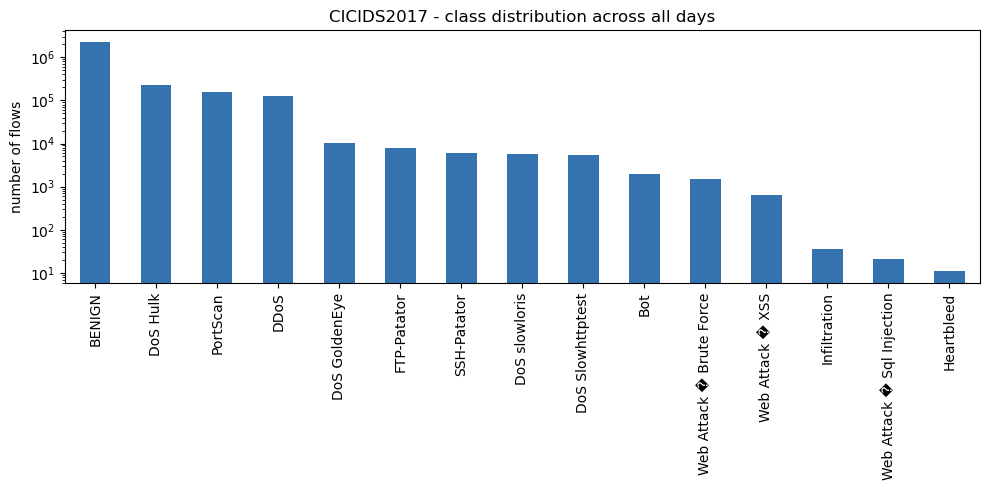

In [24]:
# Cheap pass: read only the Label column from every file to get the overall class balance
# without loading the full ~2.8M-row dataset into memory.
def clean_columns(df):
    df.columns = [c.strip() for c in df.columns]
    return df

label_counts_all = {}
for path in day_files:
    df_labels = pd.read_csv(path, usecols=lambda c: c.strip() == "Label", low_memory=False)
    df_labels = clean_columns(df_labels)
    counts = df_labels["Label"].value_counts()
    for label, count in counts.items():
        label_counts_all[label] = label_counts_all.get(label, 0) + int(count)

label_series = pd.Series(label_counts_all).sort_values(ascending=False)
print(label_series)

plt.figure(figsize=(10, 5))
label_series.plot(kind="bar", color="#3572b0")
plt.ylabel("number of flows"); plt.title("CICIDS2017 - class distribution across all days")
plt.yscale("log")  # BENIGN dwarfs the attack classes - log scale makes both visible
plt.tight_layout()
plt.savefig(f"{OUT_CYBER}/class_distribution_all_days.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Isolate and clean the Wednesday file (BENIGN + DoS attacks)

Using: ./Wednesday-workingHours.pcap_ISCX.csv
Raw shape: (692703, 79)
Labels in Wednesday file: ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']
Shape after dropping inf/NaN rows: (691406, 79)
78 numeric feature columns


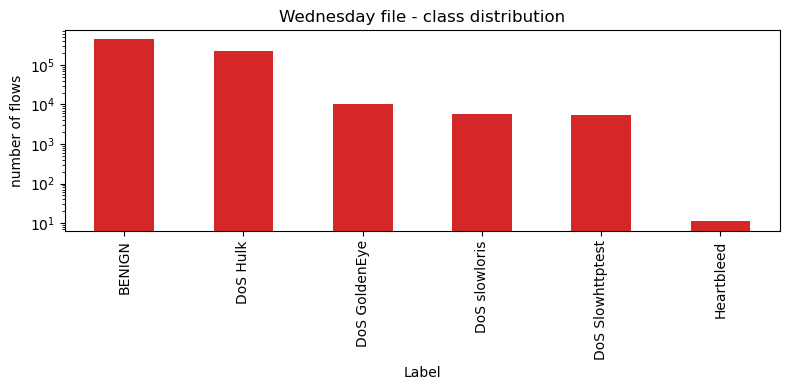

In [25]:
wednesday_path = next(p for p in day_files if "Wednesday" in os.path.basename(p))
print("Using:", wednesday_path)

df = pd.read_csv(wednesday_path, low_memory=False)
df = clean_columns(df)
print("Raw shape:", df.shape)
print("Labels in Wednesday file:", df["Label"].unique())

# CICIDS2017 is known to contain +-inf and NaN values (e.g. Flow Bytes/s, Flow Packets/s
# when a flow duration is 0) - drop any row affected rather than silently zero-filling.
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print("Shape after dropping inf/NaN rows:", df.shape)

feature_columns = [c for c in df.columns if c != "Label"]
feature_columns = [c for c in feature_columns if pd.api.types.is_numeric_dtype(df[c])]
print(f"{len(feature_columns)} numeric feature columns")

wed_label_counts = df["Label"].value_counts()
plt.figure(figsize=(8, 4))
wed_label_counts.plot(kind="bar", color="#d62728")
plt.ylabel("number of flows"); plt.title("Wednesday file - class distribution")
plt.yscale("log")
plt.tight_layout()
plt.savefig(f"{OUT_CYBER}/class_distribution_wednesday.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# BENIGN vs DoS-attack (any DoS/Heartbleed variant) - balanced subsample for GAN training.
df["is_attack"] = (df["Label"] != "BENIGN").astype(int)

benign_df = df[df["is_attack"] == 0]
attack_df = df[df["is_attack"] == 1]
print(f"BENIGN: {len(benign_df)} | DoS-attack (all variants): {len(attack_df)}")

n_per_class = min(MAX_TRAIN_PER_CLASS, len(benign_df), len(attack_df))
benign_sample = benign_df.sample(n=n_per_class, random_state=SEED)
attack_sample = attack_df.sample(n=n_per_class, random_state=SEED)
train_df = pd.concat([benign_sample, attack_sample], ignore_index=True)
train_df = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)  # shuffle
print("Training subset (balanced BENIGN/attack):", train_df.shape)

X_raw = train_df[feature_columns].values.astype(np.float32)
y_labels = train_df["Label"].values          # kept for the PCA/t-SNE colouring later
y_is_attack = train_df["is_attack"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)
n_features = X_scaled.shape[1]
print("Scaled feature matrix:", X_scaled.shape)

BENIGN: 439683 | DoS-attack (all variants): 251723
Training subset (balanced BENIGN/attack): (40000, 80)
Scaled feature matrix: (40000, 78)


## 4. Tabular GAN architecture (MLP generator/discriminator, not images)

In [27]:
class TabularGenerator(nn.Module):
    """Latent noise -> synthetic standardised feature vector. No Tanh: features are
    z-scored (StandardScaler), not bounded to [-1, 1], so a linear output layer suits them."""
    def __init__(self, z_dim=Z_DIM_CYBER, hidden=256, out_dim=n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, z):
        return self.net(z)


class TabularDiscriminator(nn.Module):
    """Feature vector -> real/fake logit."""
    def __init__(self, in_dim=n_features, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)


G = TabularGenerator().to(dev)
D = TabularDiscriminator().to(dev)
print(G); print(D)

TabularGenerator(
  (net): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=256, out_features=78, bias=True)
  )
)
TabularDiscriminator(
  (net): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)


## 5. Train the tabular GAN (BENIGN + Wednesday DoS attacks)

Adam (`lr=2e-4`, `betas=(0.5, 0.999)`), `BCEWithLogitsLoss`, one-sided label
smoothing (real target 0.9) - the same stabiliser recipe used in Parts 2.1/2.3.

epoch   1/60 | D 1.3548 | G 0.8257
epoch   5/60 | D 1.2664 | G 0.9509
epoch  10/60 | D 1.1970 | G 1.0421
epoch  15/60 | D 1.1780 | G 1.0443
epoch  20/60 | D 1.1257 | G 1.2358
epoch  25/60 | D 1.0924 | G 1.1491
epoch  30/60 | D 1.1515 | G 1.2894
epoch  35/60 | D 1.1004 | G 1.2297
epoch  40/60 | D 1.1028 | G 1.3772
epoch  45/60 | D 1.1141 | G 1.2802
epoch  50/60 | D 1.0672 | G 1.3687
epoch  55/60 | D 1.1094 | G 1.3801
epoch  60/60 | D 1.0248 | G 1.3455


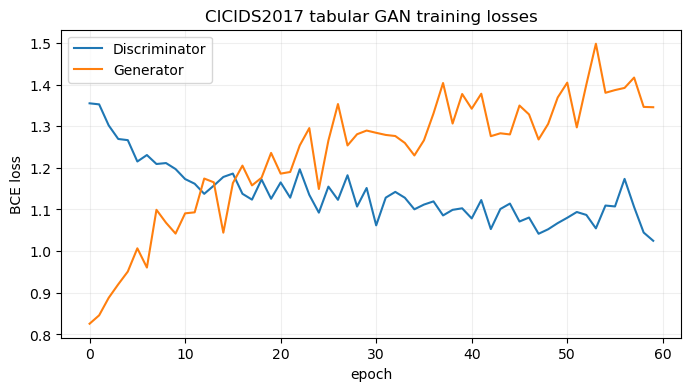

In [28]:
loader = DataLoader(TensorDataset(torch.from_numpy(X_scaled)), batch_size=BATCH,
                     shuffle=True, drop_last=True)

opt_g = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

g_hist, d_hist = [], []
for epoch in range(EPOCHS):
    for (real_batch,) in loader:
        real_batch = real_batch.to(dev)
        bs = real_batch.size(0)
        real_targets = torch.full((bs, 1), 0.9, device=dev)   # label smoothing
        fake_targets = torch.zeros((bs, 1), device=dev)

        # --- Discriminator step ---
        z = torch.randn(bs, Z_DIM_CYBER, device=dev)
        fake_batch = G(z).detach()
        d_loss = (criterion(D(real_batch), real_targets) + criterion(D(fake_batch), fake_targets))
        opt_d.zero_grad(); d_loss.backward(); opt_d.step()

        # --- Generator step ---
        z = torch.randn(bs, Z_DIM_CYBER, device=dev)
        gen_targets = torch.ones((bs, 1), device=dev)
        g_loss = criterion(D(G(z)), gen_targets)
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()

    g_hist.append(g_loss.item()); d_hist.append(d_loss.item())
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"epoch {epoch+1:>3}/{EPOCHS} | D {d_loss.item():.4f} | G {g_loss.item():.4f}")

plt.figure(figsize=(8, 4))
plt.plot(d_hist, label="Discriminator"); plt.plot(g_hist, label="Generator")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("CICIDS2017 tabular GAN training losses")
plt.legend(); plt.grid(alpha=0.2)
plt.savefig(f"{OUT_CYBER}/loss_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. Generate synthetic traffic and compare real vs fake (PCA/t-SNE)

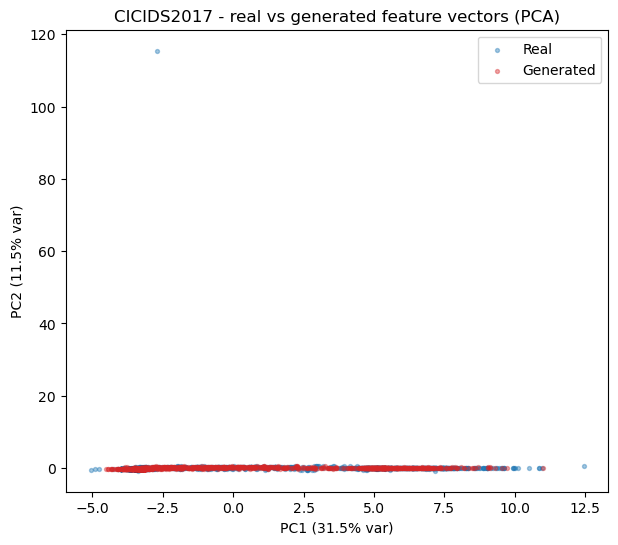

In [29]:
@torch.no_grad()
def sample_synthetic(generator, n):
    generator.eval()
    z = torch.randn(n, Z_DIM_CYBER, device=dev)
    out = generator(z).cpu().numpy()
    generator.train()
    return out

N_COMPARE = min(2000, len(X_scaled))
real_idx = np.random.choice(len(X_scaled), N_COMPARE, replace=False)
real_sample = X_scaled[real_idx]
real_sample_attack_flag = y_is_attack[real_idx]
fake_sample = sample_synthetic(G, N_COMPARE)

# --- PCA: fit on real data, project both real and fake into the same 2D space ---
pca = PCA(n_components=2, random_state=SEED)
real_pca = pca.fit_transform(real_sample)
fake_pca = pca.transform(fake_sample)

plt.figure(figsize=(7, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], s=8, alpha=0.4, label="Real", color="#1f77b4")
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], s=8, alpha=0.4, label="Generated", color="#d62728")
plt.title("CICIDS2017 - real vs generated feature vectors (PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend()
plt.savefig(f"{OUT_CYBER}/pca_real_vs_fake.png", dpi=150, bbox_inches="tight"); plt.show()

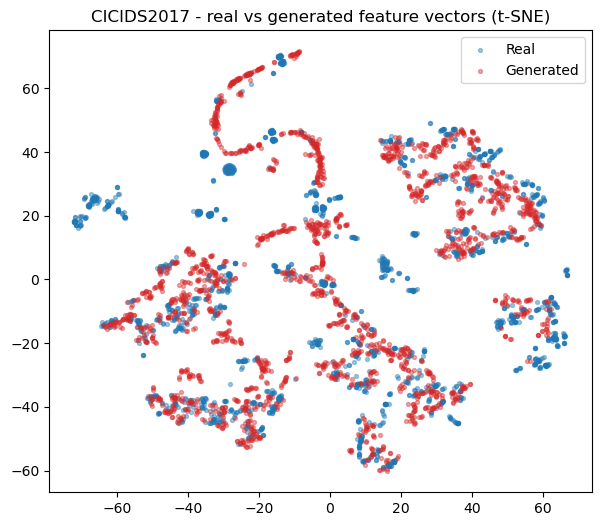

In [30]:
# --- t-SNE (slower, but often separates clusters PCA blurs together) ---
combined = np.vstack([real_sample, fake_sample])
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca")
combined_tsne = tsne.fit_transform(combined)
real_tsne, fake_tsne = combined_tsne[:N_COMPARE], combined_tsne[N_COMPARE:]

plt.figure(figsize=(7, 6))
plt.scatter(real_tsne[:, 0], real_tsne[:, 1], s=8, alpha=0.4, label="Real", color="#1f77b4")
plt.scatter(fake_tsne[:, 0], fake_tsne[:, 1], s=8, alpha=0.4, label="Generated", color="#d62728")
plt.title("CICIDS2017 - real vs generated feature vectors (t-SNE)")
plt.legend()
plt.savefig(f"{OUT_CYBER}/tsne_real_vs_fake.png", dpi=150, bbox_inches="tight"); plt.show()

## 7. Quantitative alignment check

In [31]:
# Per-feature mean/std comparison (real vs synthetic), in standardised units - a GAN
# that has learned the distribution well should have small errors here for most features.
real_mean, real_std = real_sample.mean(axis=0), real_sample.std(axis=0)
fake_mean, fake_std = fake_sample.mean(axis=0), fake_sample.std(axis=0)

mean_abs_error = np.abs(real_mean - fake_mean)
std_abs_error = np.abs(real_std - fake_std)

alignment_df = pd.DataFrame({
    "feature": feature_columns,
    "real_mean": real_mean, "fake_mean": fake_mean, "mean_abs_error": mean_abs_error,
    "real_std": real_std, "fake_std": fake_std, "std_abs_error": std_abs_error,
}).sort_values("mean_abs_error", ascending=False)

print("Worst-aligned features (largest mean error):")
print(alignment_df.head(10).to_string(index=False))
print(f"\nOverall mean |mean error| across all {len(feature_columns)} features: {mean_abs_error.mean():.4f}")
print(f"Overall mean |std error| across all {len(feature_columns)} features:  {std_abs_error.mean():.4f}")

alignment_df.to_csv(f"{OUT_CYBER}/feature_alignment.csv", index=False)

Worst-aligned features (largest mean error):
             feature  real_mean  fake_mean  mean_abs_error  real_std  fake_std  std_abs_error
      FIN Flag Count   0.037713  -0.287888        0.325601  1.040600  0.508013       0.532587
         Bwd IAT Max   0.047185  -0.237900        0.285085  1.050526  0.600676       0.449850
      URG Flag Count   0.023164  -0.236857        0.260020  1.044548  0.029630       1.014919
         Bwd IAT Std   0.050979  -0.181376        0.232355  1.062548  0.598291       0.464257
       Bwd IAT Total   0.046574  -0.181228        0.227802  1.044443  0.787554       0.256890
    Destination Port  -0.031826  -0.243221        0.211396  0.956517  0.365944       0.590573
        Fwd IAT Mean   0.008750  -0.198604        0.207354  0.971650  0.504200       0.467450
        Bwd IAT Mean   0.021045  -0.152529        0.173574  0.942895  0.368255       0.574640
min_seg_size_forward  -0.031450   0.138532        0.169983  0.998939  0.917328       0.081611
       Fwd PSH 

## 8. Reflection

*(Discussion of this run's actual outputs - the PCA/t-SNE plots and the
alignment table printed above.)*

-   **Alignment:** the generated cloud overlaps the main body of the real
    points in both the PCA and t-SNE projections, but sits slightly more
    concentrated - it captures where most real traffic lives without fully
    reaching the tails. Quantitatively the fit is good on first moments
    (**overall mean |mean error| = 0.0631** in standardised units) but
    weaker on spread (**mean |std error| = 0.3055**), i.e. the GAN matches
    average feature values far better than it matches their variance.
-   **Class structure:** the worst-aligned features (from the table) are
    dominated by timing and flag features - `Bwd IAT Max/Std/Total/Mean`,
    `FIN/URG/SYN Flag Count`, `Fwd PSH Flags` and `Destination Port`. For
    the near-binary flag counts the generated standard deviation almost
    vanishes (e.g. `URG` fake std 0.036, `SYN` 0.024, `Fwd PSH` 0.034 vs
    real ~0.9), meaning the generator effectively pins those features to a
    near-constant instead of reproducing their on/off distribution - a form
    of partial mode collapse on the discrete features.
-   **Flaws:** this matches the known failure mode of GANs on tabular
    network data - heavy-tailed count/byte features and binary flags are
    the hardest to reproduce, and they are exactly the features at the top
    of the error table.
-   **"Generating ducks" revisited:** here a fabricated-but-plausible flow
    could be genuinely dangerous rather than merely curious - a synthetic
    "attack" that is not a real attack pattern could mislead an IDS trained
    on it into missing real attacks, and a synthetic "benign" flow could
    normalise attack-like behaviour. Unlike the OCT case there is no visual
    sanity-check for tabular data, which makes the quantitative evaluation
    above more important, not less.
-   **Label caveat:** the Wednesday file contains **DoS**, not DDoS,
    despite the brief's wording; the code follows the brief literally on the
    Wednesday file and revisits true DDoS in the all-days extension.

## 9. Extension - full CICIDS2017 dataset (all days, incl. true DDoS)

In [32]:
EXT_MAX_PER_CLASS = 1000 if FAST else 8000   # smaller per-file cap - many files now

def load_and_clean(path, max_rows_per_label=EXT_MAX_PER_CLASS):
    df_day = pd.read_csv(path, low_memory=False)
    df_day = clean_columns(df_day)
    df_day = df_day.replace([np.inf, -np.inf], np.nan).dropna()
    # Cap rows per label so BENIGN (by far the largest class) doesn't dominate every file.
    df_day = df_day.groupby("Label", group_keys=False).apply(
        lambda g: g.sample(n=min(len(g), max_rows_per_label), random_state=SEED))
    return df_day

all_days_list = [load_and_clean(p) for p in day_files]
all_days_df = pd.concat(all_days_list, ignore_index=True)
print("Combined multi-day subset:", all_days_df.shape)
print(all_days_df["Label"].value_counts())

ext_feature_columns = [c for c in feature_columns if c in all_days_df.columns]
X_ext_raw = all_days_df[ext_feature_columns].values.astype(np.float32)
ext_labels = all_days_df["Label"].values

ext_scaler = StandardScaler()
X_ext_scaled = ext_scaler.fit_transform(X_ext_raw).astype(np.float32)
print("Extension feature matrix:", X_ext_scaled.shape)

/tmp/ipykernel_6009/2228408943.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_day = df_day.groupby("Label", group_keys=False).apply(
/tmp/ipykernel_6009/2228408943.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_day = df_day.groupby("Label", group_keys=False).apply(
/tmp/ipykernel_6009/2228408943.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, 

Combined multi-day subset: (125310, 79)
Label
BENIGN                        64000
DoS Hulk                       8000
DoS GoldenEye                  8000
DDoS                           8000
PortScan                       8000
FTP-Patator                    7935
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1956
Web Attack � Brute Force       1507
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64
Extension feature matrix: (125310, 78)


/tmp/ipykernel_6009/2228408943.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_day = df_day.groupby("Label", group_keys=False).apply(


[all-days] epoch   1/60 | D 1.2887 | G 0.8931
[all-days] epoch   5/60 | D 1.1562 | G 1.1521
[all-days] epoch  10/60 | D 1.1324 | G 1.2349
[all-days] epoch  15/60 | D 1.0705 | G 1.2802
[all-days] epoch  20/60 | D 0.9969 | G 1.4268
[all-days] epoch  25/60 | D 1.0021 | G 1.3811
[all-days] epoch  30/60 | D 1.0049 | G 1.4581
[all-days] epoch  35/60 | D 1.0033 | G 1.6331
[all-days] epoch  40/60 | D 0.9695 | G 1.7230
[all-days] epoch  45/60 | D 0.9447 | G 1.7564
[all-days] epoch  50/60 | D 0.9216 | G 2.0164
[all-days] epoch  55/60 | D 0.9851 | G 1.8410
[all-days] epoch  60/60 | D 0.9975 | G 1.9371


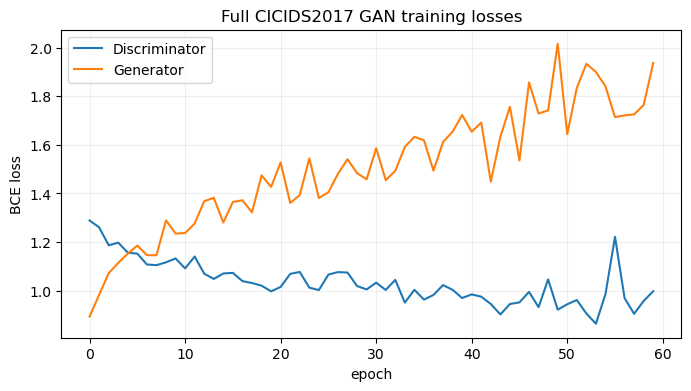

In [33]:
# Re-use the same GAN classes on the wider, more attack-diverse dataset.
G_ext = TabularGenerator(out_dim=X_ext_scaled.shape[1]).to(dev)
D_ext = TabularDiscriminator(in_dim=X_ext_scaled.shape[1]).to(dev)
opt_g_ext = torch.optim.Adam(G_ext.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d_ext = torch.optim.Adam(D_ext.parameters(), lr=2e-4, betas=(0.5, 0.999))

ext_loader = DataLoader(TensorDataset(torch.from_numpy(X_ext_scaled)), batch_size=BATCH,
                         shuffle=True, drop_last=True)

g_hist_ext, d_hist_ext = [], []
for epoch in range(EPOCHS):
    for (real_batch,) in ext_loader:
        real_batch = real_batch.to(dev)
        bs = real_batch.size(0)
        real_targets = torch.full((bs, 1), 0.9, device=dev)
        fake_targets = torch.zeros((bs, 1), device=dev)

        z = torch.randn(bs, Z_DIM_CYBER, device=dev)
        fake_batch = G_ext(z).detach()
        d_loss = criterion(D_ext(real_batch), real_targets) + criterion(D_ext(fake_batch), fake_targets)
        opt_d_ext.zero_grad(); d_loss.backward(); opt_d_ext.step()

        z = torch.randn(bs, Z_DIM_CYBER, device=dev)
        gen_targets = torch.ones((bs, 1), device=dev)
        g_loss = criterion(D_ext(G_ext(z)), gen_targets)
        opt_g_ext.zero_grad(); g_loss.backward(); opt_g_ext.step()

    g_hist_ext.append(g_loss.item()); d_hist_ext.append(d_loss.item())
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"[all-days] epoch {epoch+1:>3}/{EPOCHS} | D {d_loss.item():.4f} | G {g_loss.item():.4f}")

plt.figure(figsize=(8, 4))
plt.plot(d_hist_ext, label="Discriminator"); plt.plot(g_hist_ext, label="Generator")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("Full CICIDS2017 GAN training losses")
plt.legend(); plt.grid(alpha=0.2)
plt.savefig(f"{OUT_CYBER}/loss_curves_full_dataset.png", dpi=150, bbox_inches="tight"); plt.show()

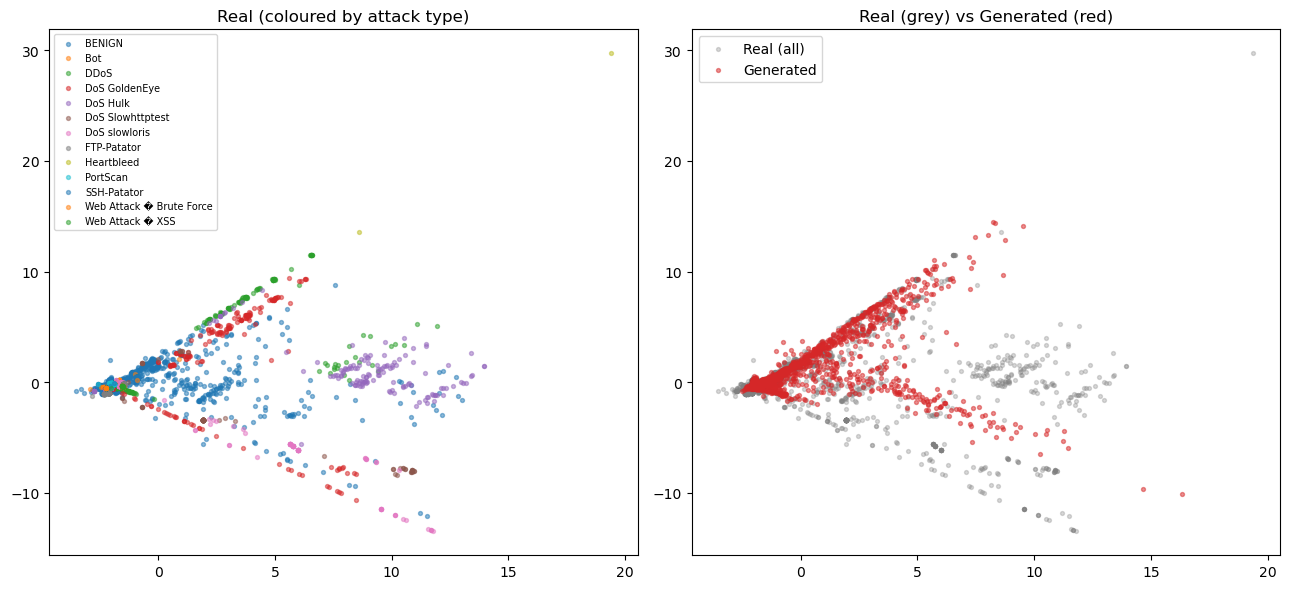

In [34]:
# PCA on the full dataset, coloured by attack TYPE (not just binary) to check whether
# the GAN captures the structure of multiple distinct attack categories at once.
N_EXT_COMPARE = min(3000, len(X_ext_scaled))
ext_idx = np.random.choice(len(X_ext_scaled), N_EXT_COMPARE, replace=False)
real_ext_sample = X_ext_scaled[ext_idx]
real_ext_labels_sample = ext_labels[ext_idx]
fake_ext_sample = sample_synthetic(G_ext, N_EXT_COMPARE)

pca_ext = PCA(n_components=2, random_state=SEED)
real_ext_pca = pca_ext.fit_transform(real_ext_sample)
fake_ext_pca = pca_ext.transform(fake_ext_sample)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for label in np.unique(real_ext_labels_sample):
    mask = real_ext_labels_sample == label
    axes[0].scatter(real_ext_pca[mask, 0], real_ext_pca[mask, 1], s=8, alpha=0.5, label=label)
axes[0].set_title("Real (coloured by attack type)"); axes[0].legend(fontsize=7, loc="best")
axes[1].scatter(real_ext_pca[:, 0], real_ext_pca[:, 1], s=8, alpha=0.3, label="Real (all)", color="grey")
axes[1].scatter(fake_ext_pca[:, 0], fake_ext_pca[:, 1], s=8, alpha=0.5, label="Generated", color="#d62728")
axes[1].set_title("Real (grey) vs Generated (red)"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT_CYBER}/pca_full_dataset_by_attack_type.png", dpi=150, bbox_inches="tight"); plt.show()

In [35]:
# Extension: quantitative alignment (mirrors the Wednesday-only check in section 7)
real_ext_mean, real_ext_std = real_ext_sample.mean(axis=0), real_ext_sample.std(axis=0)
fake_ext_mean, fake_ext_std = fake_ext_sample.mean(axis=0), fake_ext_sample.std(axis=0)

ext_alignment = pd.DataFrame({
    "feature": ext_feature_columns,
    "real_mean": real_ext_mean, "fake_mean": fake_ext_mean,
    "mean_abs_error": np.abs(real_ext_mean - fake_ext_mean),
    "real_std": real_ext_std, "fake_std": fake_ext_std,
    "std_abs_error": np.abs(real_ext_std - fake_ext_std),
}).sort_values("mean_abs_error", ascending=False)

print("Extension - worst-aligned features (all days):")
print(ext_alignment.head(10))
print(f"\nMean |mean-gap| (all-days): {ext_alignment['mean_abs_error'].mean():.4f}")
print(f"Mean |std-gap|  (all-days): {ext_alignment['std_abs_error'].mean():.4f}")

Extension - worst-aligned features (all days):
                  feature  real_mean  fake_mean  mean_abs_error  real_std  \
47         ACK Flag Count  -0.005243  -0.497358        0.492115  0.998180   
48         URG Flag Count   0.019285  -0.342702        0.361987  1.024292   
11  Bwd Packet Length Min  -0.014265   0.321898        0.336164  0.959834   
20          Fwd IAT Total  -0.022108  -0.324688        0.302580  0.980008   
1           Flow Duration  -0.020865  -0.323390        0.302525  0.980920   
30          Fwd PSH Flags  -0.024454  -0.297725        0.273271  0.961191   
44         SYN Flag Count  -0.024454  -0.297263        0.272809  0.961191   
18           Flow IAT Max  -0.024513  -0.288909        0.264396  0.973256   
76               Idle Max  -0.027760  -0.290253        0.262494  0.969924   
23            Fwd IAT Max  -0.026093  -0.279716        0.253622  0.973049   

    fake_std  std_abs_error  
47  0.613687       0.384493  
48  0.037121       0.987171  
11  1.120981   

## Extension reflection

*(Discussion of this run's actual outputs - compare the two alignment
printouts.)*

Trained across every attack type at once, the generator's PCA cloud covers
the dense central region of the combined data - where BENIGN and the
high-volume attacks (`DoS Hulk`, and now true `DDoS` from the Friday file)
sit - but under-represents the outlying, rarer clusters. That is expected:
a single unconditional generator has no incentive to spend capacity on
classes it rarely sees, and several categories are extremely rare even
after per-file capping (`Heartbleed` ~11 rows, `Infiltration` ~36,
`Web Attack - Sql Injection` ~21).

Comparing back to the Wednesday-only result in sections 6-7: adding more
attack diversity made the alignment **worse, not better** - overall mean
|mean error| rose from **0.0631** (Wednesday only) to **0.1330** (all
days), and mean |std error| from **0.3055** to **0.4125**. The extra days
add more *modes* for one generator to cover, and that cost outweighed the
benefit of having more total training data. The practical takeaway is that
this vanilla unconditional GAN does **not** generalise cleanly to a
many-attack setting; a class-conditional GAN (as built for OCT in Part 2.1)
or one model per attack family would be the natural next step to give the
rarer attack types dedicated capacity.

---

# Part 2.3 - Creative AI: QuickDraw 'birthday cake' sketches with a DCGAN

Goal: train a DCGAN to generate birthday-cake sketches from Google's QuickDraw dataset, then compare real vs fake visually and with FID.

**Steps**
1. Download and explore the 'birthday cake' category (sample sketches + a basic complexity check).
2. Train a DCGAN - reusing the `Generator` / `Discriminator` / `kaiming_init` architecture from Part 2.1, plus the instance-noise + dropout + D-step-skip stabiliser (defined in Part 2.1 but not used there - it under-performed on OCT, but works well here on line-art sketches).
3. Track G/D losses and snapshot samples across epochs.
4. Generate fakes, compare real vs fake visually and via FID (reusing the InceptionV3 feature extractor already loaded in Part 2.1).
5. (Extension) Repeat for 1-2 more QuickDraw categories and compare how sketch complexity affects results.

**Dataset citation:** Google Creative Lab, *The Quick, Draw! Dataset* (https://github.com/googlecreativelab/quickdraw-dataset). Downloaded from the public `numpy_bitmap` mirror on Google Cloud Storage - requires **Internet: ON**.

> Run this after Part 2.1 in the same session: it reuses `Generator`, `Discriminator`, `kaiming_init`, `dev`, `Z_DIM`, `to_tensor`, `show_grid`, `inception_features` and `fid_score` defined above rather than redefining them.

---

# Part 2.3 - Creative AI: QuickDraw 'birthday cake' DCGAN (TensorFlow/Keras)

QuickDraw 'numpy bitmap' files are 28x28 grayscale sketches. We download the 'birthday
cake' category, train a **TensorFlow/Keras DCGAN**, evaluate with FID, and extend to
extra categories to compare sketch complexity.

In [36]:
# --- Part 2.3 configuration (QuickDraw DCGAN, TensorFlow) ---
QD_LATENT = 128
QD_NGF = 64
QD_NDF = 64
QD_LR = 0.0002
QD_BETA1 = 0.5
QD_EPOCHS = 30
QD_BATCH = 128
QD_MAX_IMAGES = 30000
QD_FID_SAMPLES = 2000
QD_INIT = "dcgan"
QD_EXTRA_CATEGORIES = ['cat', 'house']
print("QuickDraw TF config:", dict(latent=QD_LATENT, ngf=QD_NGF, ndf=QD_NDF, lr=QD_LR,
                                   epochs=QD_EPOCHS, batch=QD_BATCH, init=QD_INIT))

QuickDraw TF config: {'latent': 128, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'epochs': 30, 'batch': 128, 'init': 'dcgan'}


## 2.3.1 - Download and explore 'birthday cake'

birthday cake sketches: (144982, 28, 28)


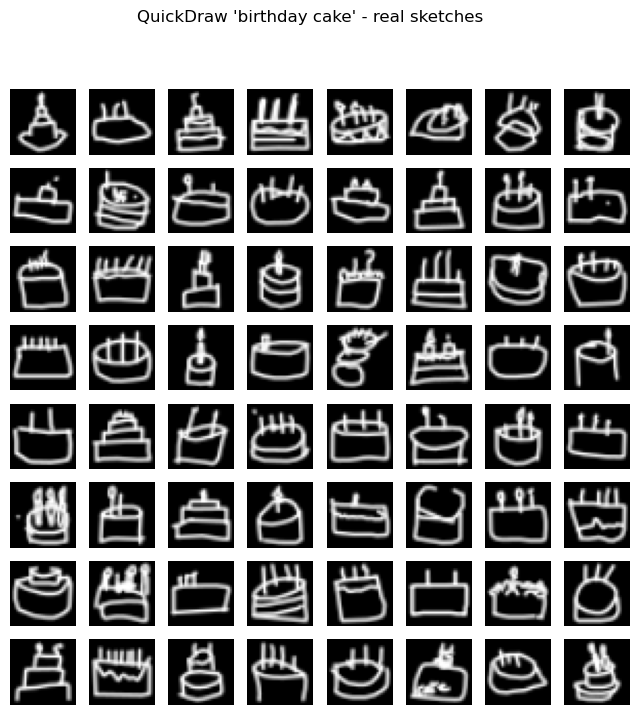

In [37]:
def download_quickdraw_bitmaps(category_name, destination_dir):
    """Download a QuickDraw 'numpy bitmap' category -> (N, 28, 28) uint8. Needs Internet: ON."""
    import urllib.request
    os.makedirs(destination_dir, exist_ok=True)
    encoded = category_name.replace(" ", "%20")
    url = f"https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/{encoded}.npy"
    local_path = os.path.join(destination_dir, f"{category_name.replace(' ', '_')}.npy")
    if not os.path.exists(local_path):
        print(f"downloading QuickDraw '{category_name}' ...")
        request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request) as response, open(local_path, "wb") as handle:
            handle.write(response.read())
    return np.load(local_path).reshape(-1, 28, 28)


def sketch_ink_density(images_uint8, threshold=50):
    """Mean fraction of 'inked' pixels - a simple sketch-complexity proxy."""
    return float((images_uint8 > threshold).mean())


quickdraw_dir = os.path.join(TF_RESULTS_DIR, "quickdraw_data")
cake_images = download_quickdraw_bitmaps("birthday cake", quickdraw_dir)
print("birthday cake sketches:", cake_images.shape)
tf_show_grid(preprocess_tf_images(cake_images[:64]), "QuickDraw 'birthday cake' - real sketches",
             os.path.join(TF_RESULTS_DIR, "quickdraw_real_samples.png"))

## 2.3.2 - Build and train the DCGAN

epoch   1/30 | D=0.3630 | G=4.3437
epoch   2/30 | D=0.5773 | G=3.0653
epoch   3/30 | D=0.5496 | G=3.0037
epoch   4/30 | D=0.4516 | G=3.2233
epoch   5/30 | D=0.4284 | G=2.9019
epoch   6/30 | D=0.4054 | G=3.2549
epoch   7/30 | D=1.0040 | G=4.5679
epoch   8/30 | D=0.3917 | G=3.3270
epoch   9/30 | D=0.7017 | G=1.4749
epoch  10/30 | D=0.3688 | G=4.1802
epoch  11/30 | D=0.4044 | G=3.2996
epoch  12/30 | D=0.3605 | G=4.3567
epoch  13/30 | D=0.3568 | G=4.6827
epoch  14/30 | D=0.6962 | G=1.6906
epoch  15/30 | D=0.3464 | G=5.0978
epoch  16/30 | D=0.3555 | G=5.3230
epoch  17/30 | D=0.3658 | G=4.0598
epoch  18/30 | D=0.3433 | G=5.3389
epoch  19/30 | D=0.6751 | G=1.7180
epoch  20/30 | D=0.3420 | G=5.3923
epoch  21/30 | D=0.5969 | G=1.8543
epoch  22/30 | D=0.3576 | G=4.1801
epoch  23/30 | D=0.3510 | G=5.3699
epoch  24/30 | D=0.6236 | G=1.8275
epoch  25/30 | D=0.4162 | G=3.4981
epoch  26/30 | D=0.3386 | G=5.4475
epoch  27/30 | D=0.3404 | G=5.5593
epoch  28/30 | D=0.3472 | G=4.7078
epoch  29/30 | D=0.3

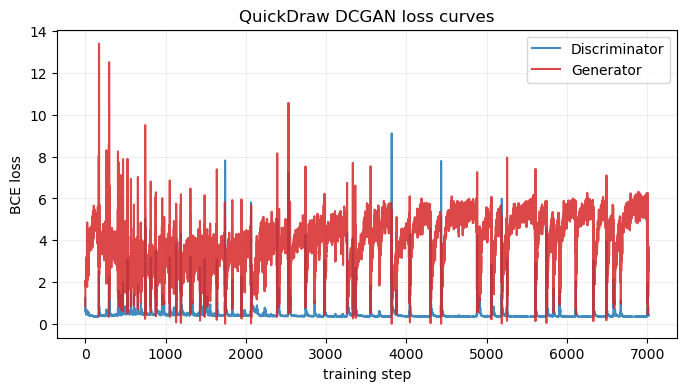

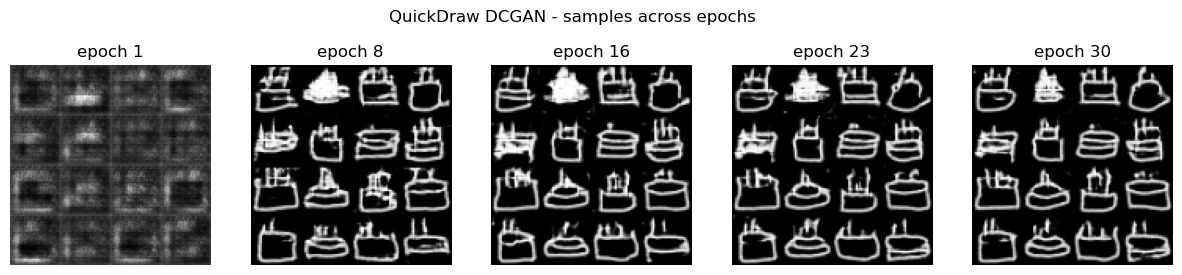

In [38]:
np.random.seed(TF_SEED); tf.random.set_seed(TF_SEED)

cake_subset = np.random.permutation(len(cake_images))[:QD_MAX_IMAGES]
cake_x = preprocess_tf_images(cake_images[cake_subset])
cake_dataset = (tf.data.Dataset.from_tensor_slices(cake_x)
                .shuffle(min(len(cake_x), 10000))
                .batch(QD_BATCH, drop_remainder=True)
                .prefetch(tf.data.AUTOTUNE))

cake_generator = build_dcgan_generator(QD_LATENT, QD_NGF, weight_init=QD_INIT)
cake_discriminator = build_dcgan_discriminator(QD_NDF, weight_init=QD_INIT)

cake_d_hist, cake_g_hist, cake_snaps = train_dcgan(
    cake_generator, cake_discriminator, cake_dataset,
    QD_EPOCHS, QD_LATENT, learning_rate=QD_LR, beta_1=QD_BETA1)

tf_plot_losses(cake_d_hist, cake_g_hist, "QuickDraw DCGAN loss curves",
               os.path.join(TF_RESULTS_DIR, "quickdraw_loss_curves.png"))
tf_show_epoch_progression(cake_snaps, "QuickDraw DCGAN - samples across epochs",
                          os.path.join(TF_RESULTS_DIR, "quickdraw_progression.png"))

## 2.3.3 - Generate, compare real vs fake, and compute FID

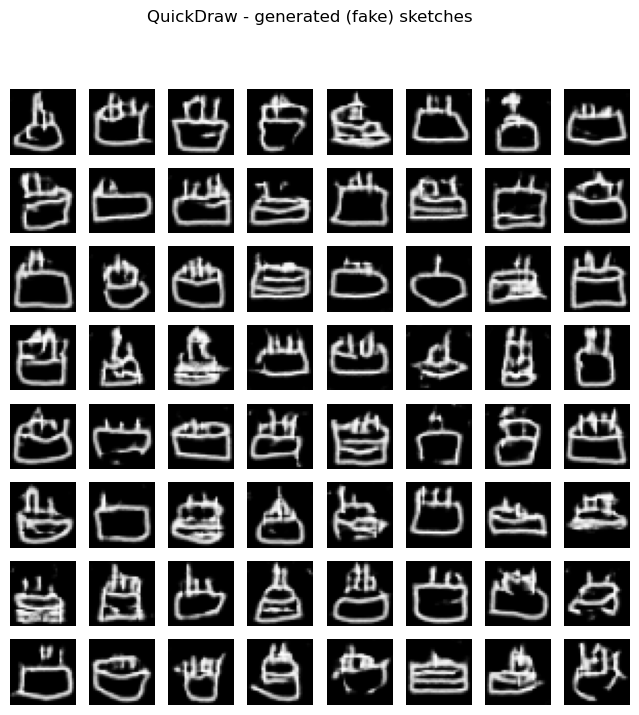

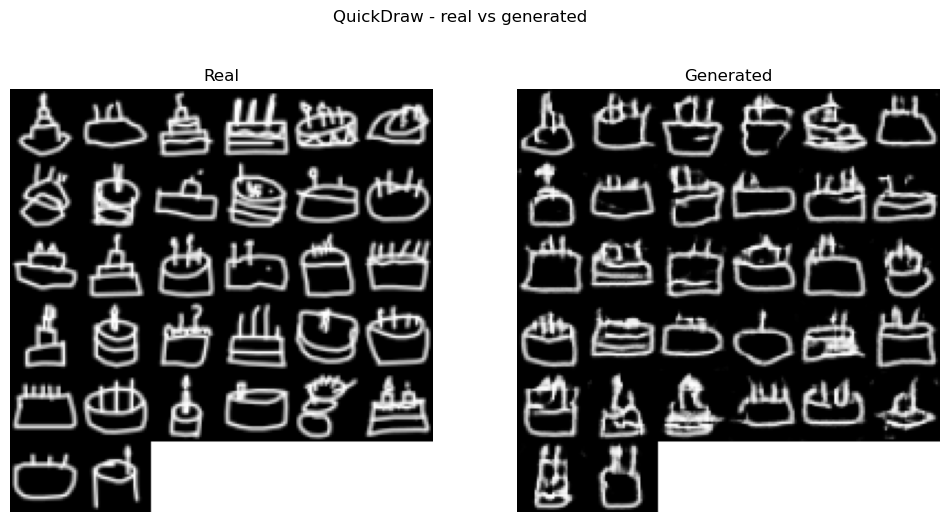

QuickDraw 'birthday cake' DCGAN FID (lower is better): 40.80


In [39]:
cake_fake = generate_tf_images(cake_generator, QD_FID_SAMPLES, QD_LATENT)
tf_show_grid(cake_fake[:64], "QuickDraw - generated (fake) sketches",
             os.path.join(TF_RESULTS_DIR, "quickdraw_fake_samples.png"))
tf_show_real_vs_fake(preprocess_tf_images(cake_images[:32]), cake_fake[:32],
                     "QuickDraw - real vs generated", os.path.join(TF_RESULTS_DIR, "quickdraw_real_vs_fake.png"))

cake_fid_idx = np.random.permutation(len(cake_images))[:QD_FID_SAMPLES]
cake_real_unit = to_unit_range(preprocess_tf_images(cake_images[cake_fid_idx]))
cake_fid = frechet_inception_distance(cake_real_unit, to_unit_range(cake_fake))
print(f"QuickDraw 'birthday cake' DCGAN FID (lower is better): {cake_fid:.2f}")

## 2.3 (extension) - Other categories and sketch-complexity comparison

We train the same DCGAN on additional categories and compare an **ink-density** proxy
(mean fraction of inked pixels) against FID - denser sketches are usually harder to model.

epoch   1/30 | D=0.4859 | G=2.7818
epoch   2/30 | D=0.4150 | G=3.5444
epoch   3/30 | D=0.4562 | G=3.6795
epoch   4/30 | D=0.5474 | G=2.0124
epoch   5/30 | D=0.5025 | G=2.1643
epoch   6/30 | D=0.4970 | G=3.0980
epoch   7/30 | D=1.6402 | G=3.8502
epoch   8/30 | D=0.6653 | G=1.5703
epoch   9/30 | D=0.4141 | G=3.5893
epoch  10/30 | D=0.5356 | G=2.0314
epoch  11/30 | D=0.4137 | G=3.0765
epoch  12/30 | D=0.4100 | G=3.1767
epoch  13/30 | D=0.3820 | G=3.5423
epoch  14/30 | D=0.3620 | G=4.0061
epoch  15/30 | D=0.3560 | G=4.6234
epoch  16/30 | D=0.6110 | G=1.7965
epoch  17/30 | D=4.8318 | G=7.4472
epoch  18/30 | D=0.4419 | G=3.0965
epoch  19/30 | D=0.3664 | G=5.3211
epoch  20/30 | D=0.3630 | G=4.0661
epoch  21/30 | D=0.3534 | G=4.9477
epoch  22/30 | D=0.3451 | G=5.0393
epoch  23/30 | D=0.3459 | G=4.7530
epoch  24/30 | D=0.3572 | G=4.7603
epoch  25/30 | D=0.3553 | G=5.8243
epoch  26/30 | D=0.3550 | G=4.5762
epoch  27/30 | D=0.3710 | G=5.4199
epoch  28/30 | D=0.4544 | G=2.7943
epoch  29/30 | D=0.3

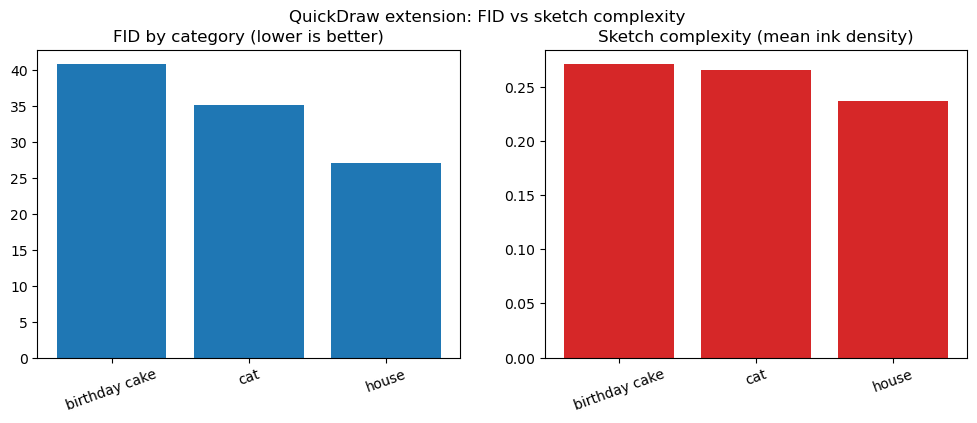

Category summary (FID | ink density):
   birthday cake: FID=40.80 | ink=0.2708
             cat: FID=35.16 | ink=0.2655
           house: FID=27.00 | ink=0.2368


In [40]:
category_fid = {"birthday cake": cake_fid}
category_ink = {"birthday cake": sketch_ink_density(cake_images)}

for extra_category in QD_EXTRA_CATEGORIES:
    np.random.seed(TF_SEED); tf.random.set_seed(TF_SEED)
    extra_images = download_quickdraw_bitmaps(extra_category, quickdraw_dir)
    category_ink[extra_category] = sketch_ink_density(extra_images)

    extra_subset = np.random.permutation(len(extra_images))[:QD_MAX_IMAGES]
    extra_dataset = (tf.data.Dataset.from_tensor_slices(preprocess_tf_images(extra_images[extra_subset]))
                     .shuffle(min(QD_MAX_IMAGES, 10000)).batch(QD_BATCH, drop_remainder=True)
                     .prefetch(tf.data.AUTOTUNE))
    extra_generator = build_dcgan_generator(QD_LATENT, QD_NGF, weight_init=QD_INIT)
    extra_discriminator = build_dcgan_discriminator(QD_NDF, weight_init=QD_INIT)
    train_dcgan(extra_generator, extra_discriminator, extra_dataset,
                QD_EPOCHS, QD_LATENT, learning_rate=QD_LR, beta_1=QD_BETA1)

    extra_fake = generate_tf_images(extra_generator, QD_FID_SAMPLES, QD_LATENT)
    extra_idx = np.random.permutation(len(extra_images))[:QD_FID_SAMPLES]
    extra_fid = frechet_inception_distance(
        to_unit_range(preprocess_tf_images(extra_images[extra_idx])), to_unit_range(extra_fake))
    category_fid[extra_category] = extra_fid
    print(f"QuickDraw '{extra_category}': FID={extra_fid:.2f} | ink density={category_ink[extra_category]:.4f}")

names = list(category_fid.keys())
figure, (fid_axis, ink_axis) = plt.subplots(1, 2, figsize=(12, 4))
fid_axis.bar(names, [category_fid[n] for n in names], color="#1f77b4")
fid_axis.set_title("FID by category (lower is better)"); fid_axis.tick_params(axis="x", rotation=20)
ink_axis.bar(names, [category_ink[n] for n in names], color="#d62728")
ink_axis.set_title("Sketch complexity (mean ink density)"); ink_axis.tick_params(axis="x", rotation=20)
figure.suptitle("QuickDraw extension: FID vs sketch complexity")
figure.savefig(os.path.join(TF_RESULTS_DIR, "quickdraw_extension_complexity.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Category summary (FID | ink density):")
for name in names:
    print(f"  {name:>14}: FID={category_fid[name]:.2f} | ink={category_ink[name]:.4f}")

## 2.3.4 - Reflection (write this section yourself, from your run)

Prompts for your own analysis of the birthday-cake generator (this notebook trains it with
an explicit `tf.GradientTape` loop over `Sequential` models):
- Are the cake body, candles and plate recognisable in the samples, or does the generator
  settle on a few repeated outlines (mode collapse)? Compare against the real grid.
- Follow the per-step discriminator/generator loss trace and the epoch snapshot grids -
  does detail build up steadily, or do the losses swing about?
- After adding the cat and house categories, check whether the ink-density ordering lines
  up with the FID ordering, and explain the cases where it does not (outline and pose
  variety make a category hard, not the raw count of inked pixels).
- Hallucination ("ducks"): the model can draw confident strokes that depict nothing real -
  a caveat whenever generated sketches are reused downstream.

## Save all outputs to `results_set1/` and zip them

Every figure produced above is written into `results_set1/`. This final cell also sweeps up any stray figures from the working directory and packages the whole folder as `results_set1.zip` for download.

In [41]:
import os
import glob
import shutil

RESULTS_DIR = "results_set1"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Move any figures written to the working directory into the results folder.
for figure_path in glob.glob("*.png"):
    shutil.move(figure_path, os.path.join(RESULTS_DIR, os.path.basename(figure_path)))

zip_archive_path = shutil.make_archive("results_set1", "zip", RESULTS_DIR)
print("All outputs saved in :", os.path.abspath(RESULTS_DIR))
print("Zipped archive       :", os.path.abspath(zip_archive_path))

All outputs saved in : /home/ec2-user/SageMaker/results_set1
Zipped archive       : /home/ec2-user/SageMaker/results_set1.zip
